# Viz_GDGU_loc — Result Visualization

Reads CSV + JSON from `results/<DATE_FOLDER>/` (produced by `train.py` or `run_experiments.py`).  
All figures are saved to the same date folder as PDF.  
**Edit Cell 1 to set paths and style overrides.**

In [1]:
# Cell 1 — Config (edit here)
# ============================================================
DATE_FOLDER = '2026-04-20_21'   # ← change to your results folder name
BUS_SYSTEM  = '34bus'            # '34bus' or '123bus'

# Style overrides — passed to apply_style(); see src/visualization.py STYLE dict
STYLE_OVERRIDES = {
    # Font — Times New Roman for all text
    'font_family':   'Times New Roman',
    'fs_label':      26,
    'fs_tick':       20,
    'fs_legend':     20,
    'fs_subtitle':   22,
    'fs_annotation': 18,

    # Colors — 5 methods (Original, GDGU, GIF, IDEA, Retrain)
    'colors': {
        'Original': "#C7CADE",
        'GDGU':     "#F7AC53",
        'GIF':      "#52AADC",
        'IDEA':     "#EC6E66",
        'Retrain':  "#6ADD6E",
    },
    'markers': {
        'Original': 'o',
        'GDGU':     's',
        'GIF':      'D',
        'IDEA':     'P',
        'Retrain':  '^',
    },
    'ideal_line_color': 'red',
    'grid_alpha':       0.3,
    'bar_alpha':        0.85,
    'bar_edge_color':   'black',
    'bar_edge_width':   0.5,
    'fill_alpha':       0.15,

    # Save
    'save_fmt': 'pdf',
    'save_dpi': 300,
}

In [2]:
# Cell 2 — Setup
import sys, json
from pathlib import Path

PROJECT_ROOT = Path('..').resolve()
sys.path.insert(0, str(PROJECT_ROOT))

from src.visualization import (apply_style, load_results, plot_all,
                                plot_khop_comparison, plot_khop_forget_size)

%load_ext autoreload
%autoreload 2

apply_style(STYLE_OVERRIDES)

# All outputs (CSV, JSON, figures) live in the same date folder
RESULTS_DIR = PROJECT_ROOT / 'results' / DATE_FOLDER
df, scenarios, backbones = load_results(str(RESULTS_DIR), BUS_SYSTEM)

# Show metadata from epoch logs if available
log_path = RESULTS_DIR / f'{BUS_SYSTEM}_epoch_logs.json'
if log_path.exists():
    with open(log_path) as f:
        meta = json.load(f).get('_metadata', {})
    print(f"\nTimestamp : {meta.get('timestamp', 'N/A')}")
    print(f"Device   : {meta.get('device', 'N/A')}")
    d = meta.get('data', {})
    print(f"Graphs={d.get('n_graphs')}, Nodes={d.get('n_nodes')}, "
          f"Features={d.get('n_feat')}, EVCS={d.get('n_evcs')}")
    for name, n_params in meta.get('model_params', {}).items():
        print(f"  {name}: {n_params:,} params")

Loaded 450 rows from /home/Nanhong147/1P_WTT_NVD/Projects/4-GU_EV_loc/results/2026-04-20_21/34bus_results_raw.csv
  Backbones : ['GAT', 'GCN', 'GIN']
  Scenarios : ['S1-0', 'S2-0', 'S3-0']
  Methods   : ['GDGU', 'GIF', 'IDEA', 'Original', 'Retrain']

Timestamp : 2026-04-21 00:43:27
Device   : cuda:0
Graphs=2000, Nodes=37, Features=48, EVCS=3
  GAT: 391,299 params
  GCN: 73,347 params
  GIN: 122,883 params


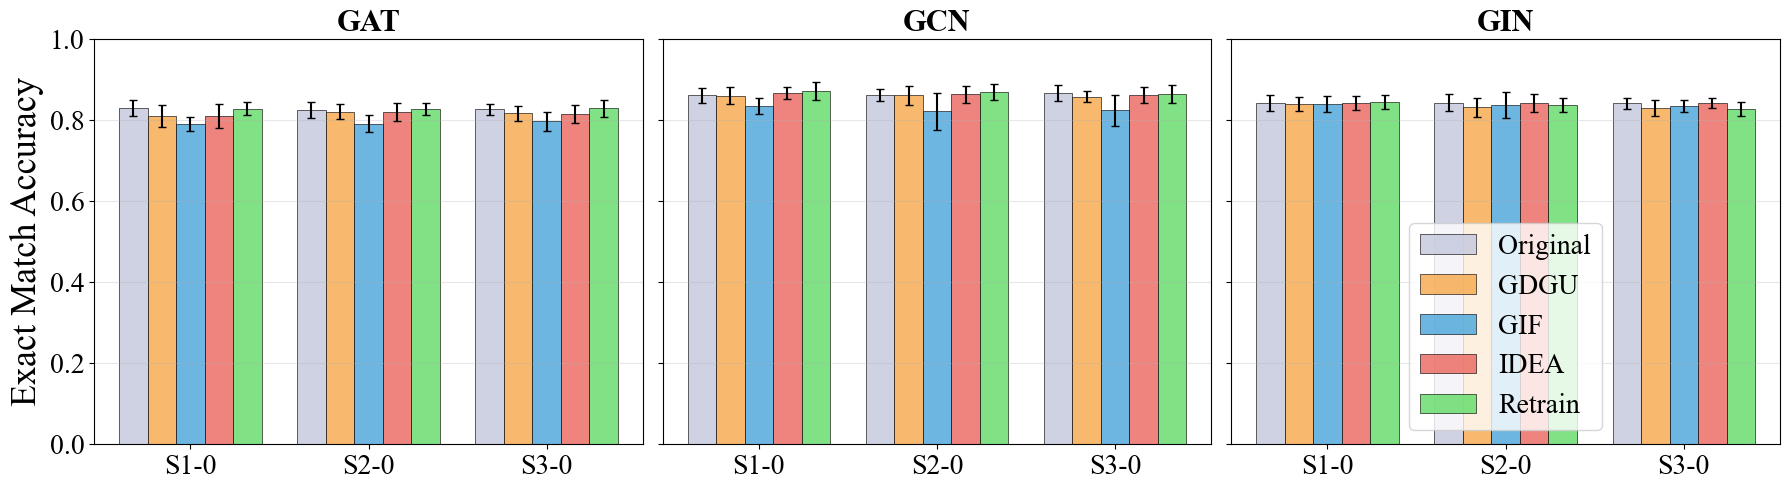

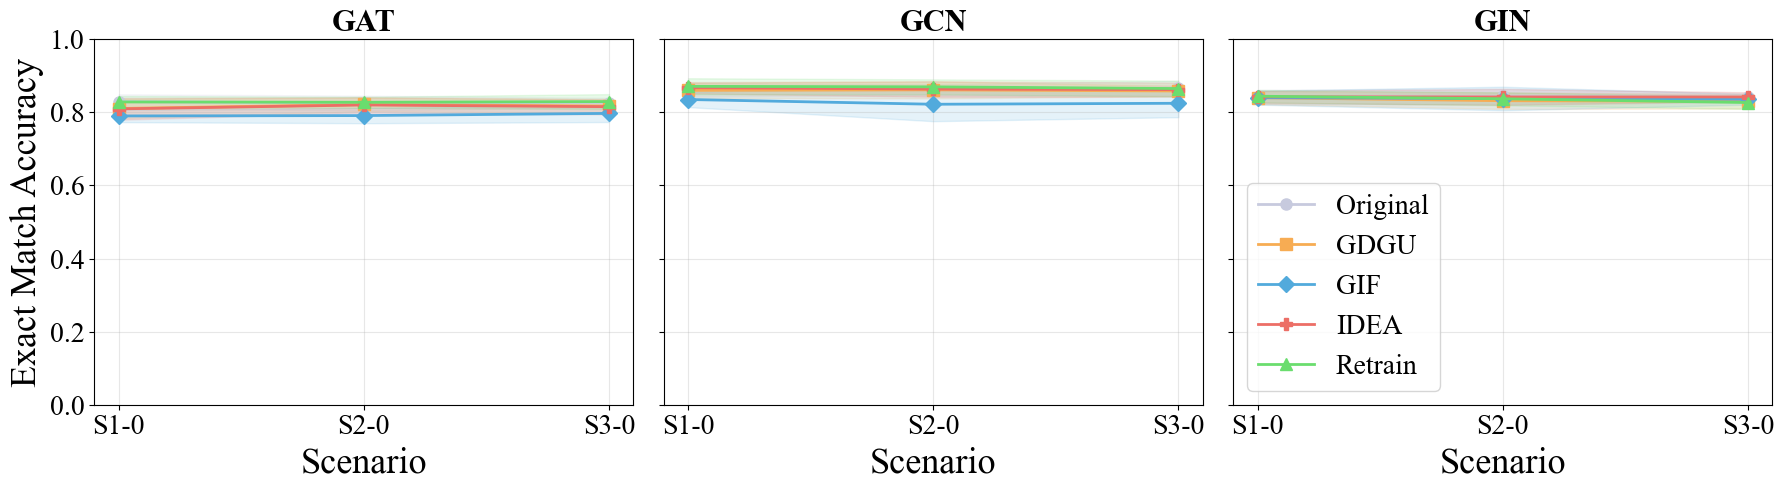

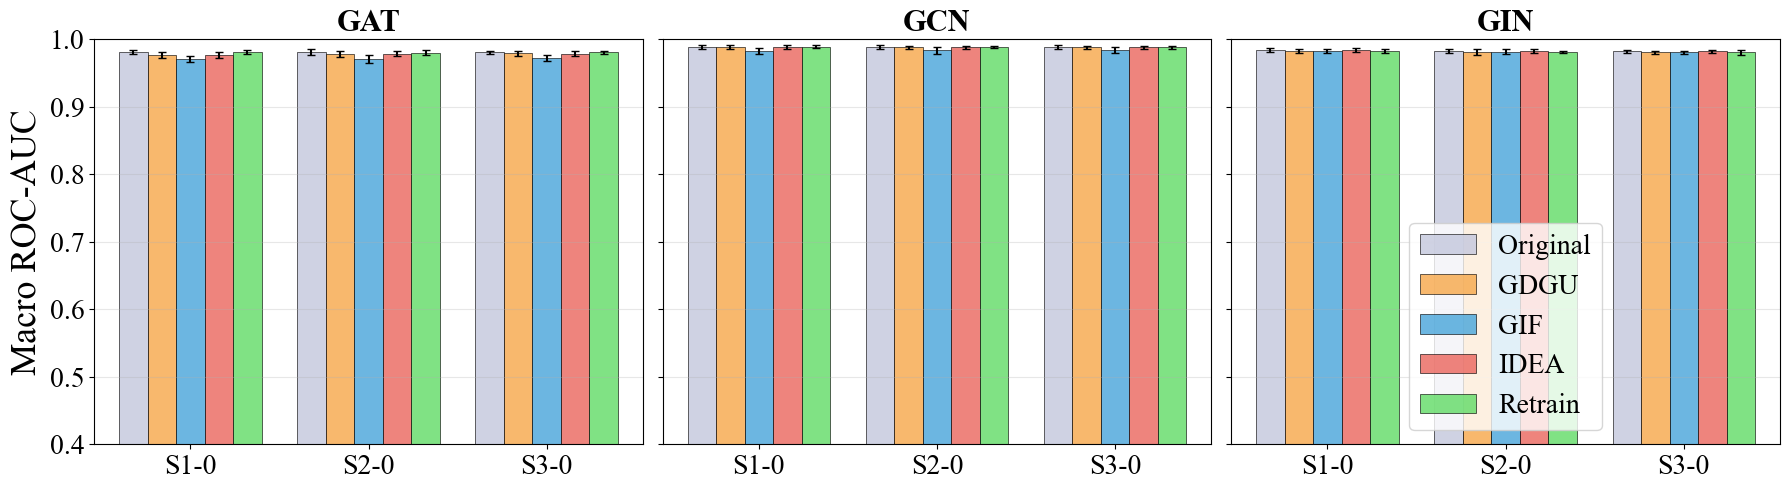

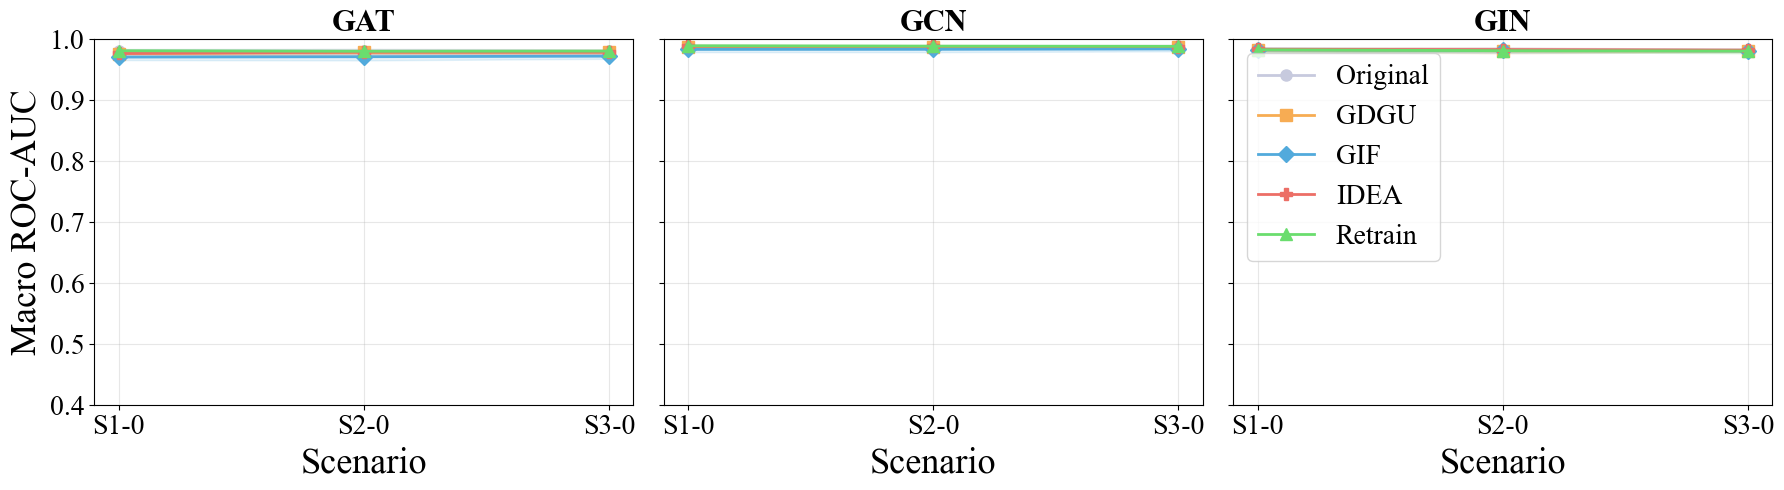

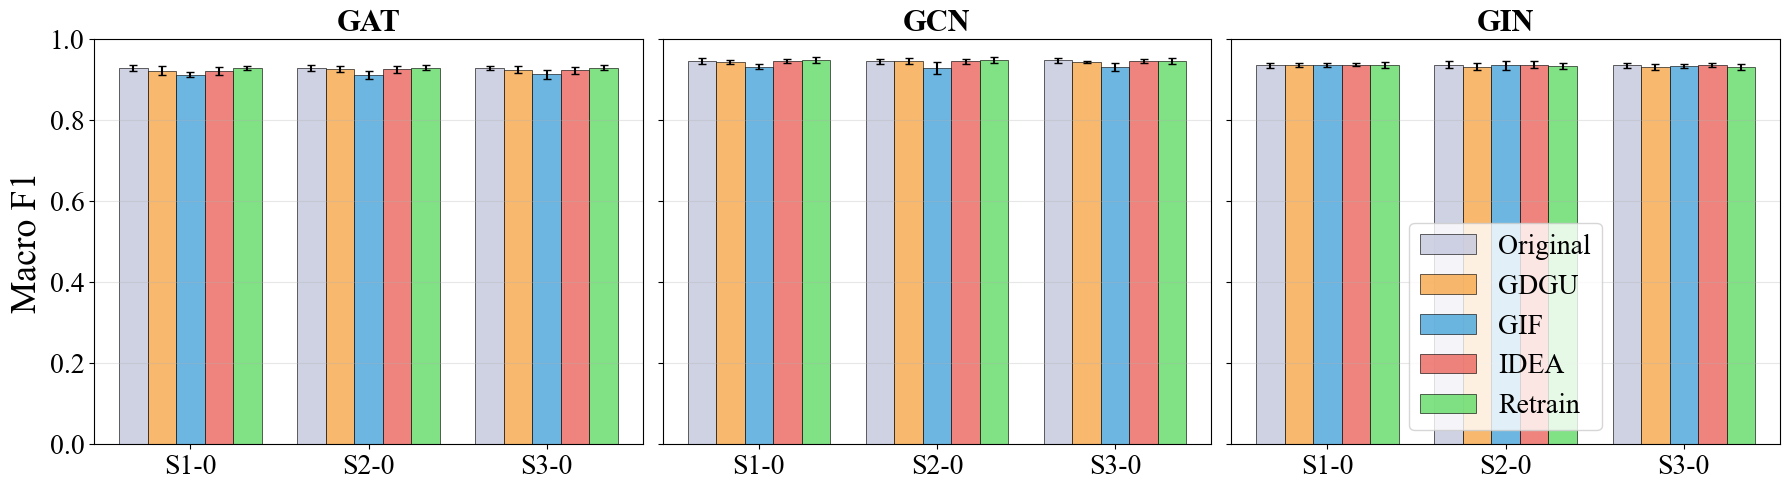

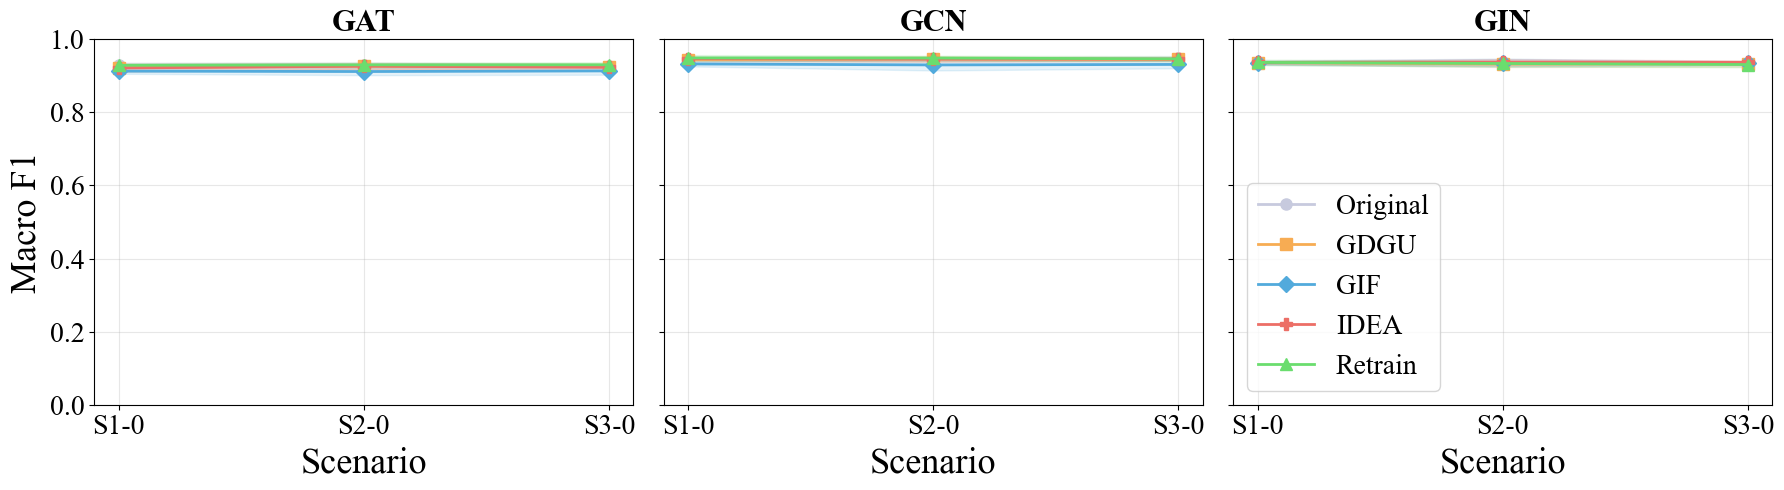

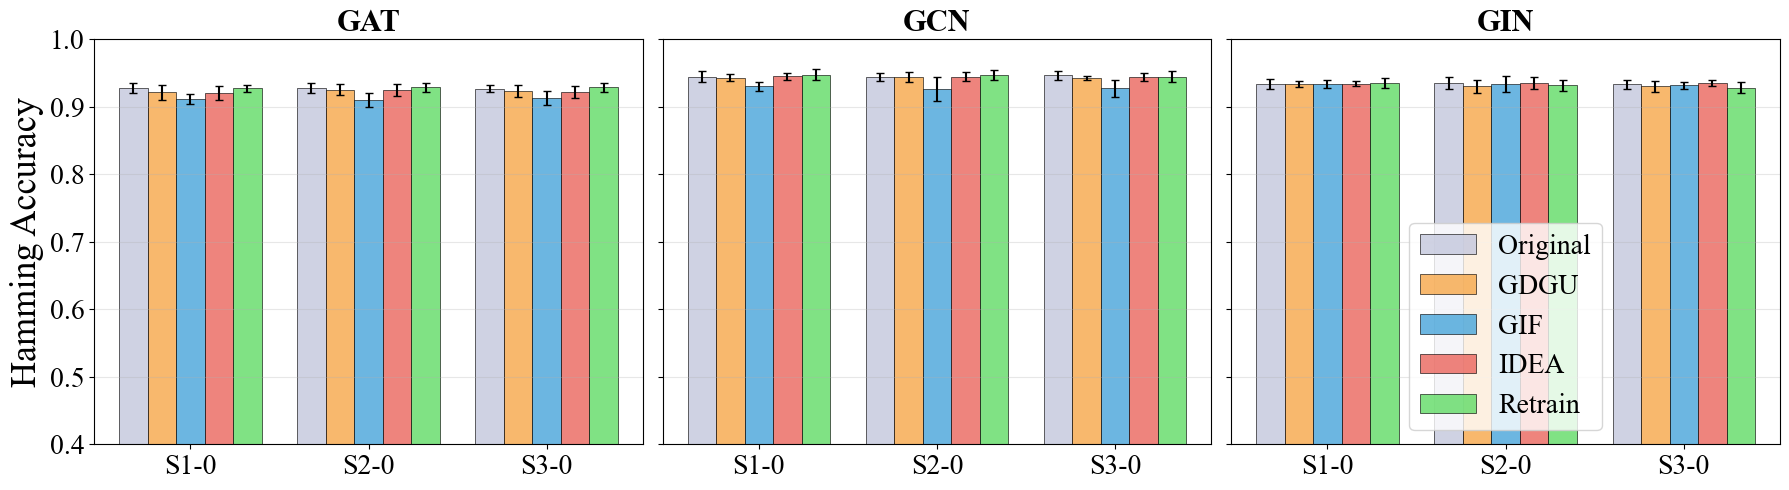

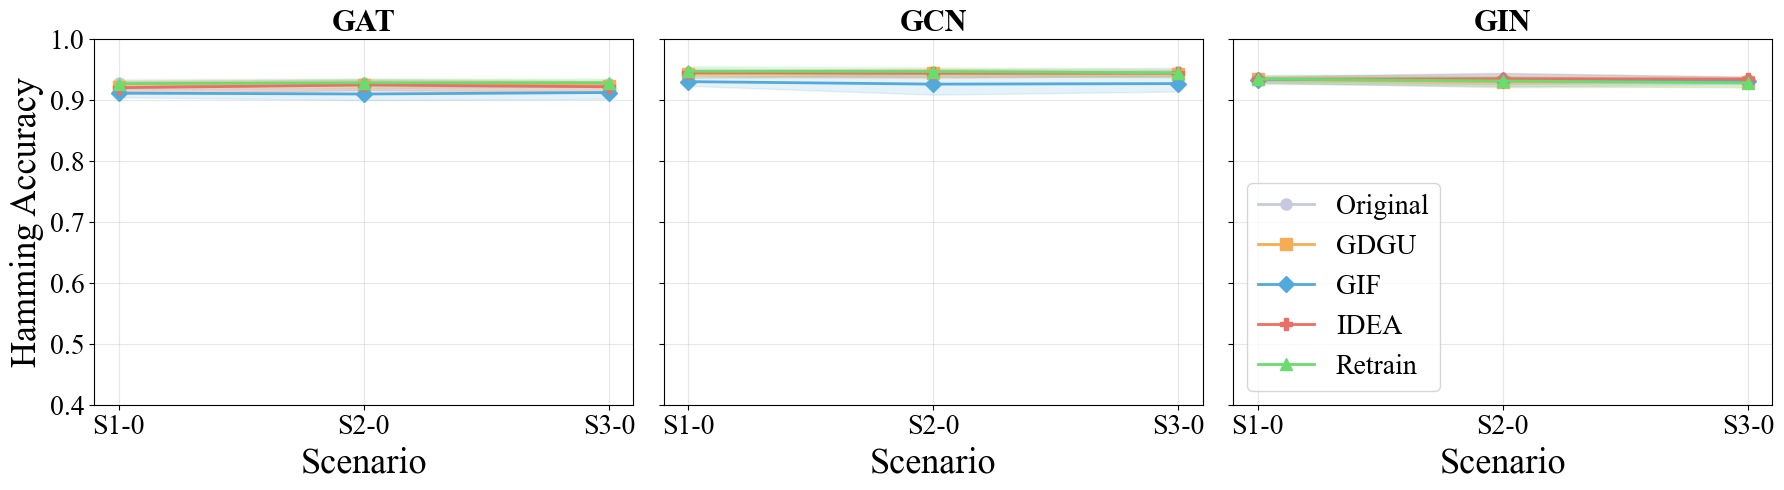

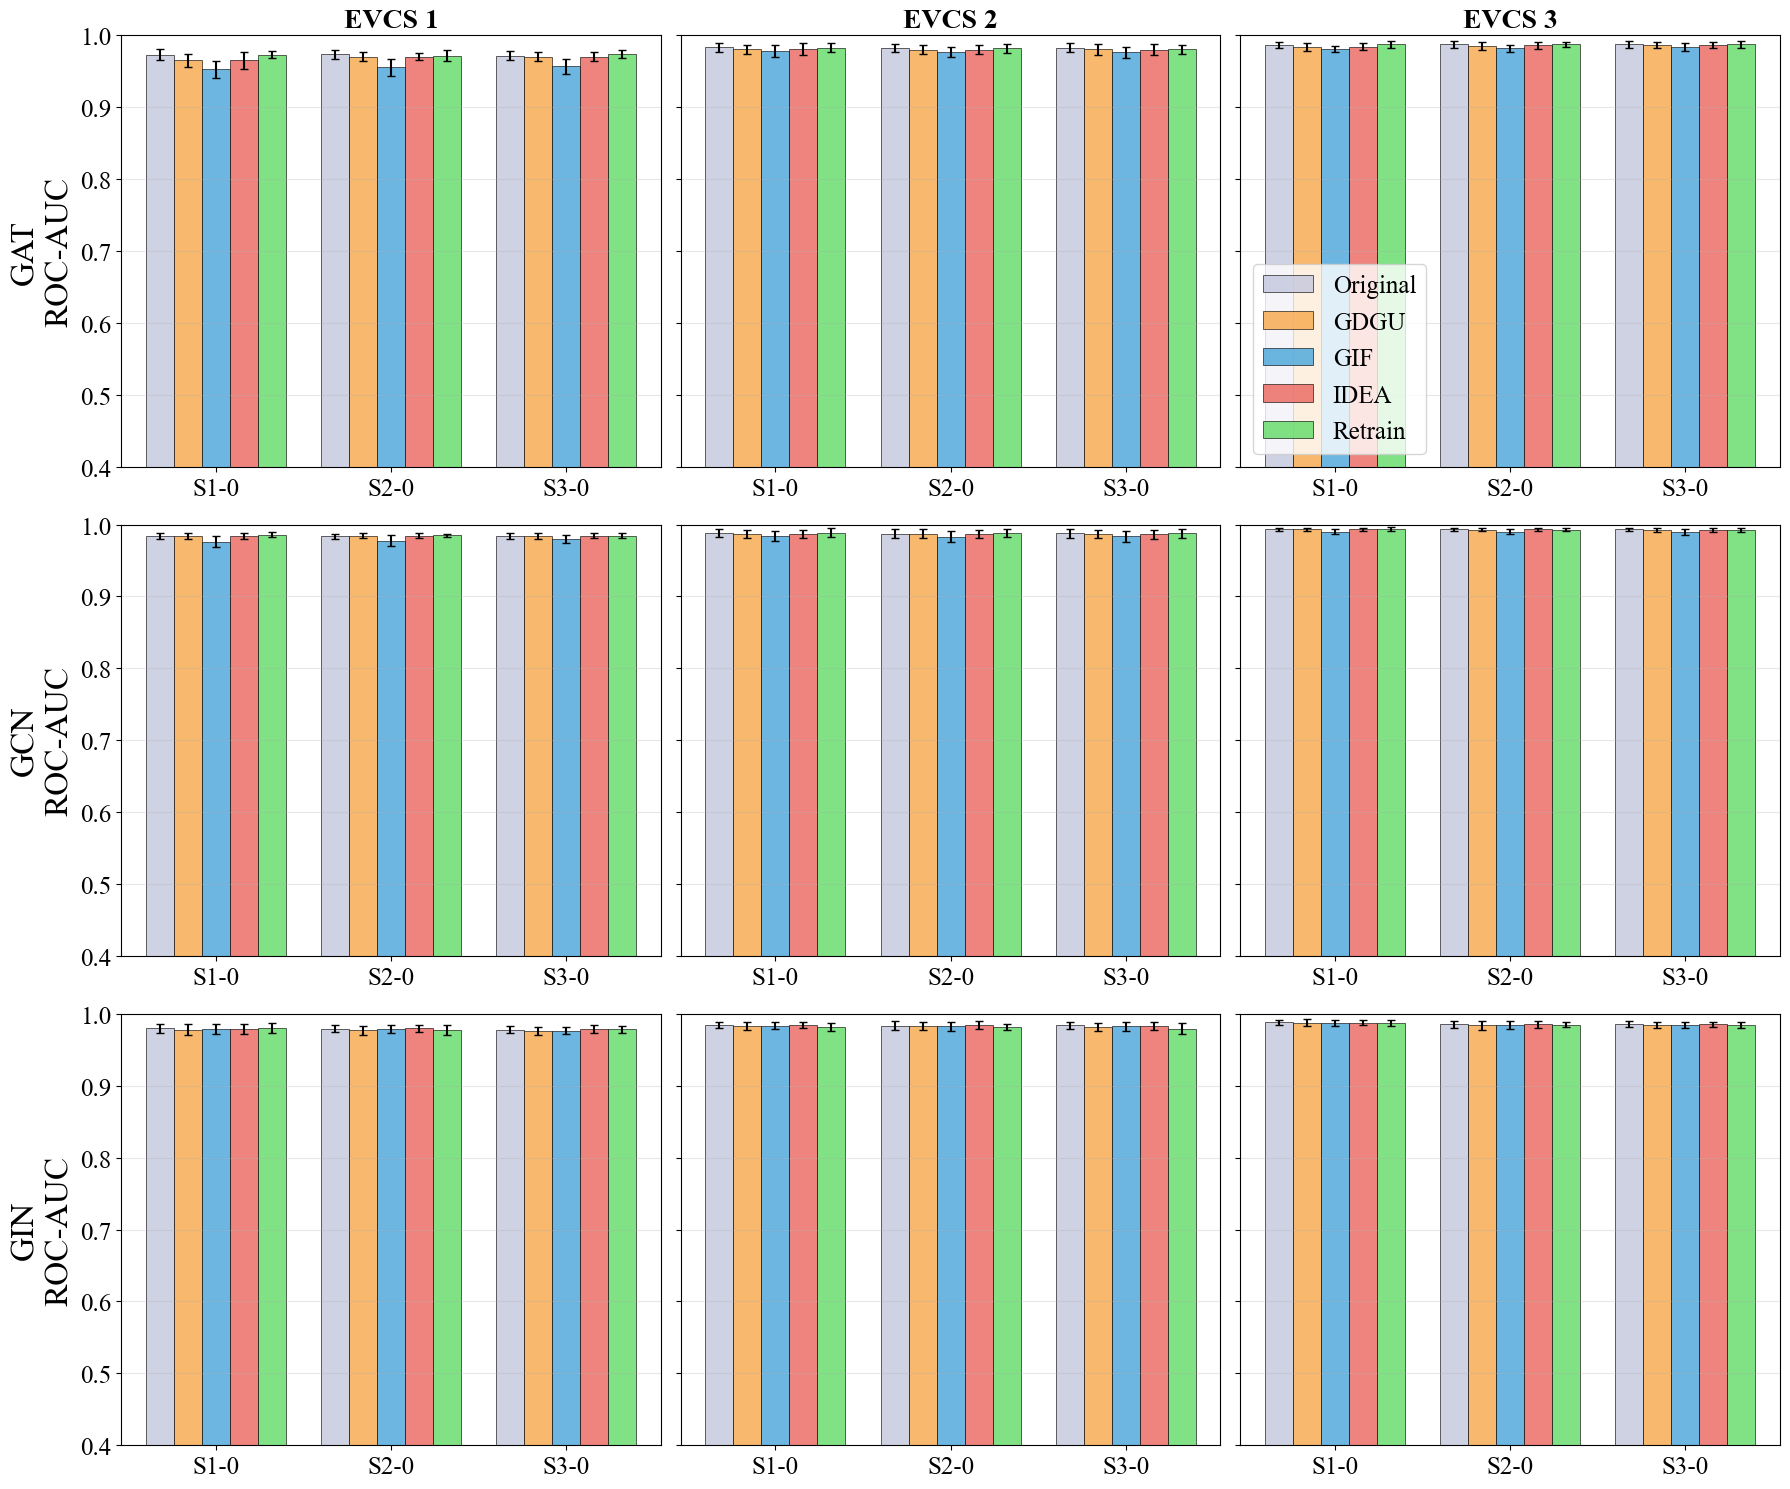

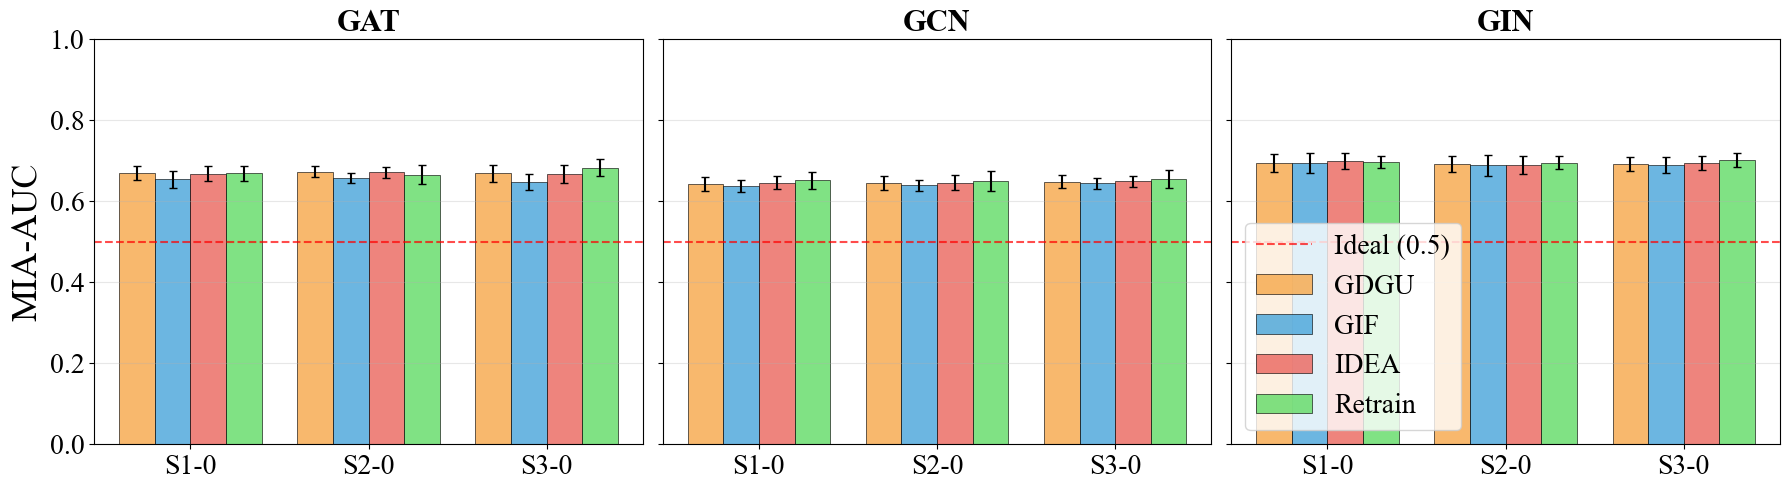

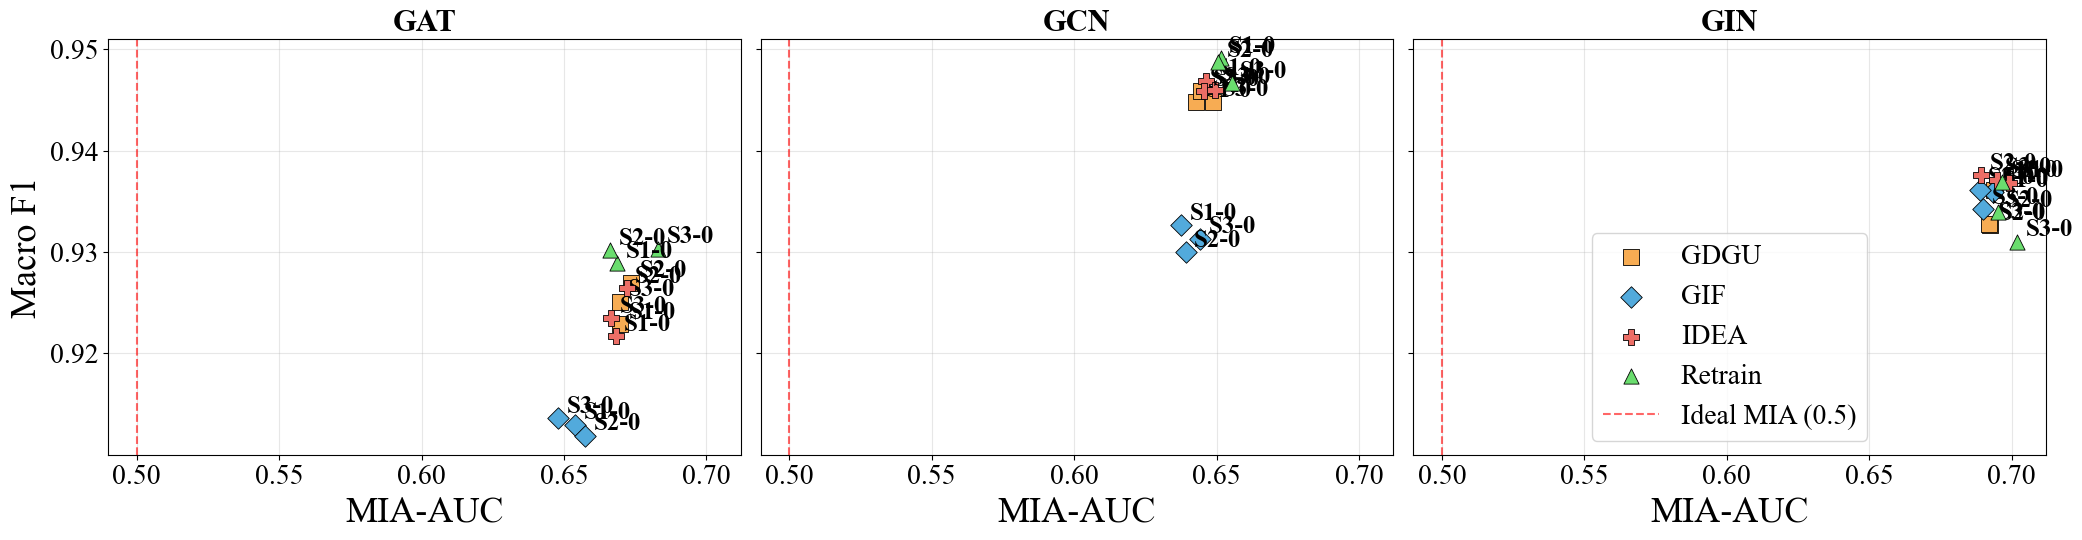

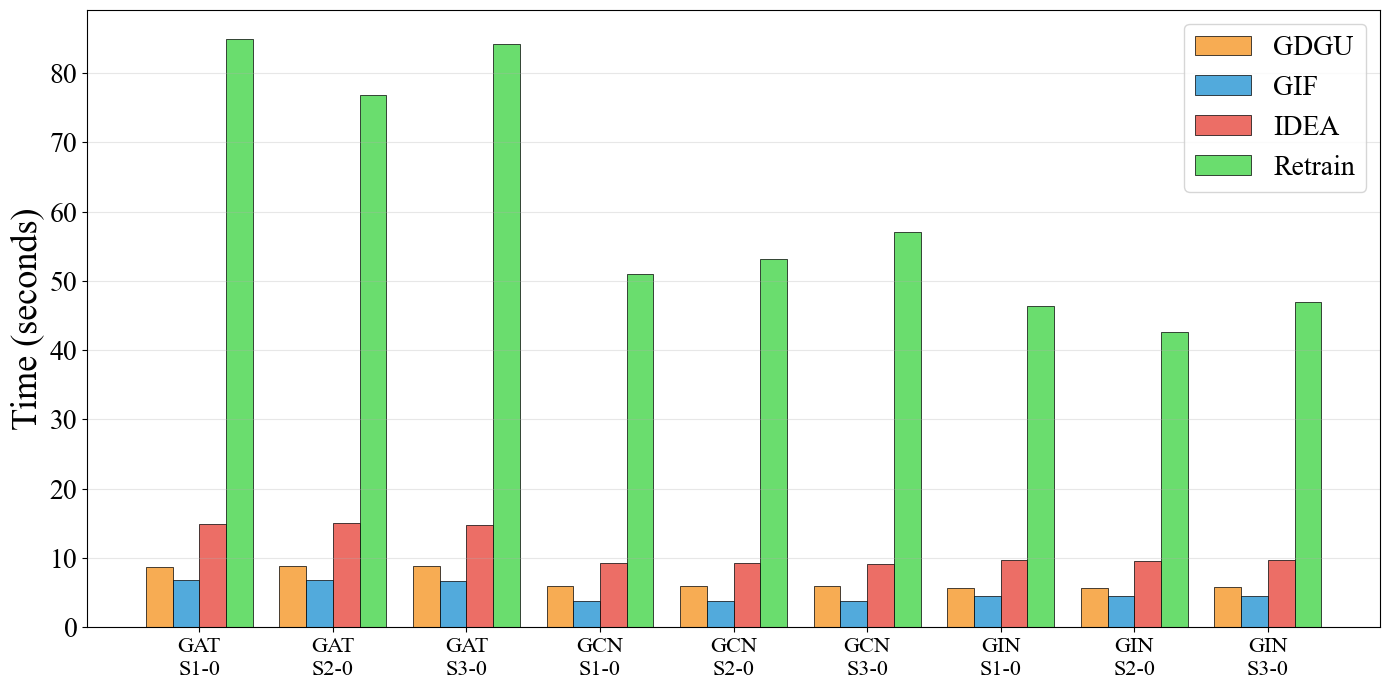

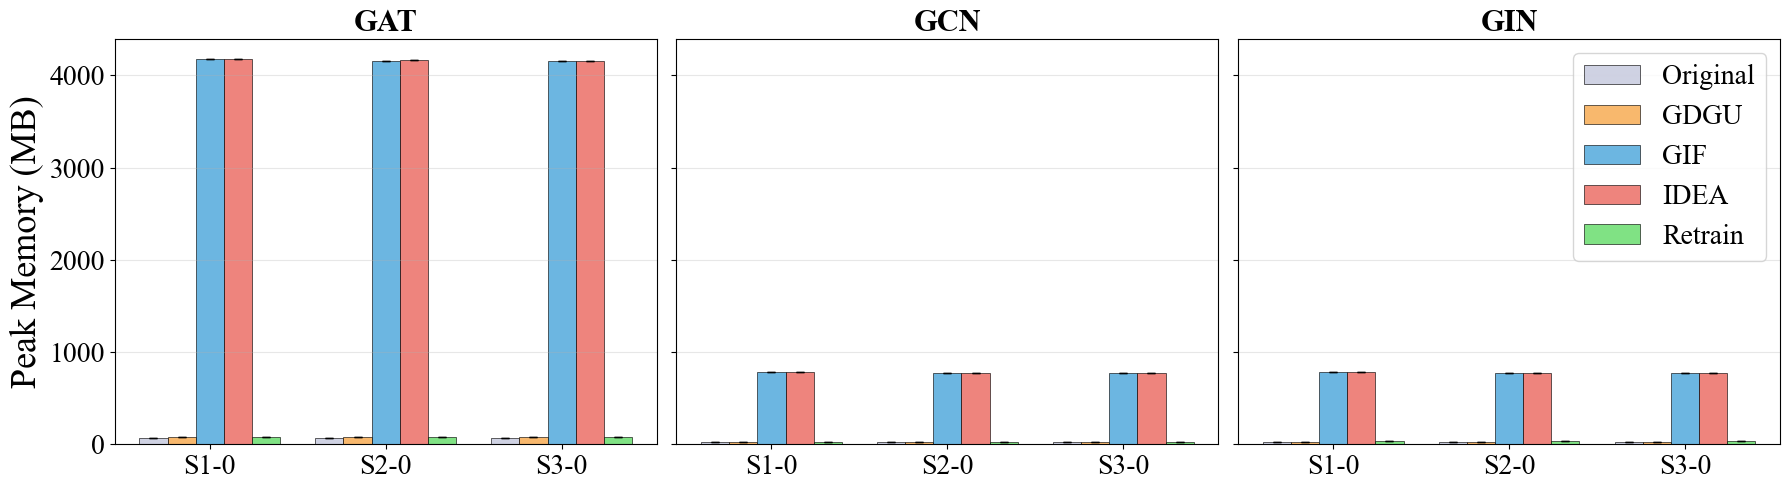

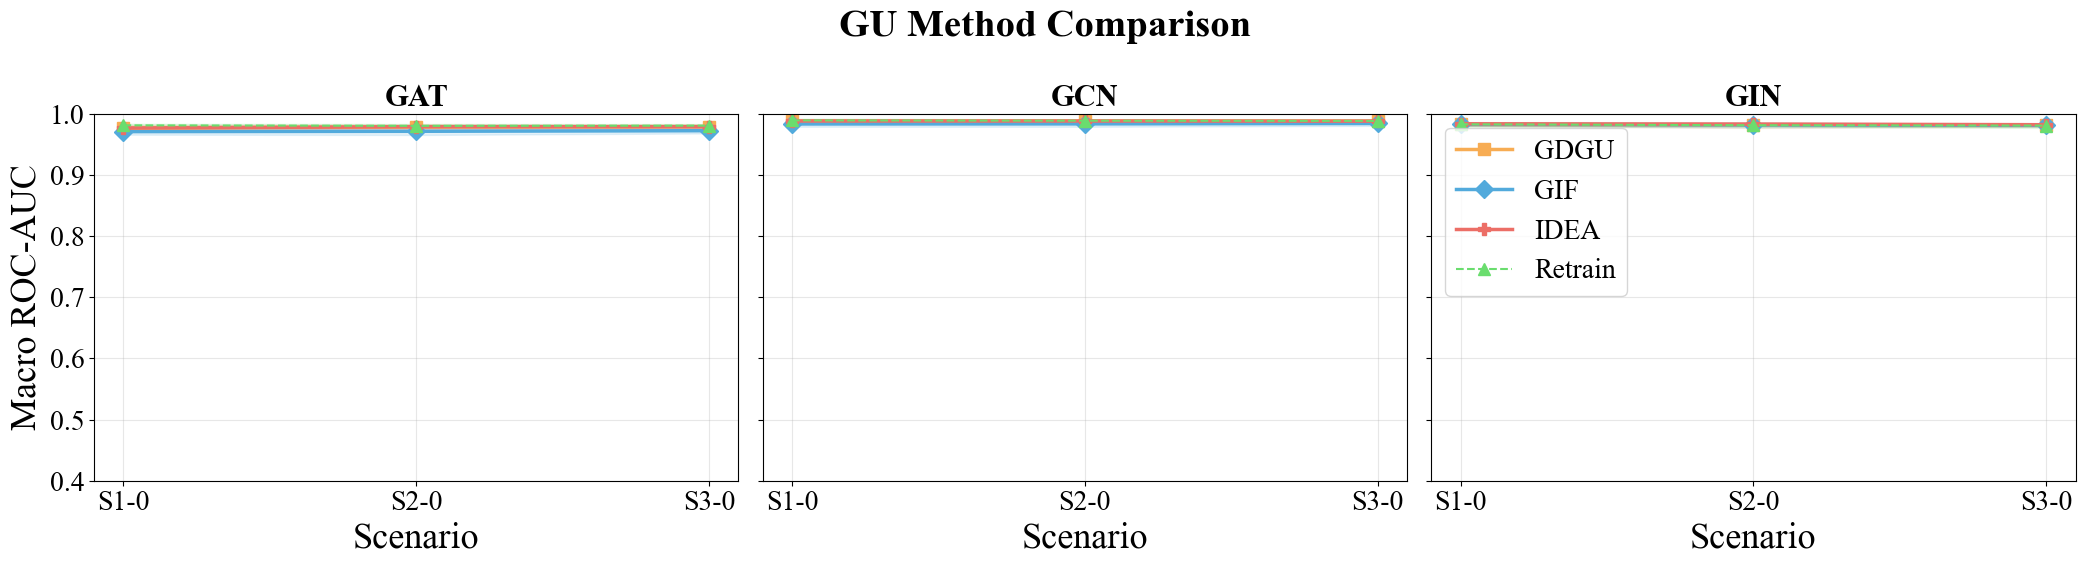

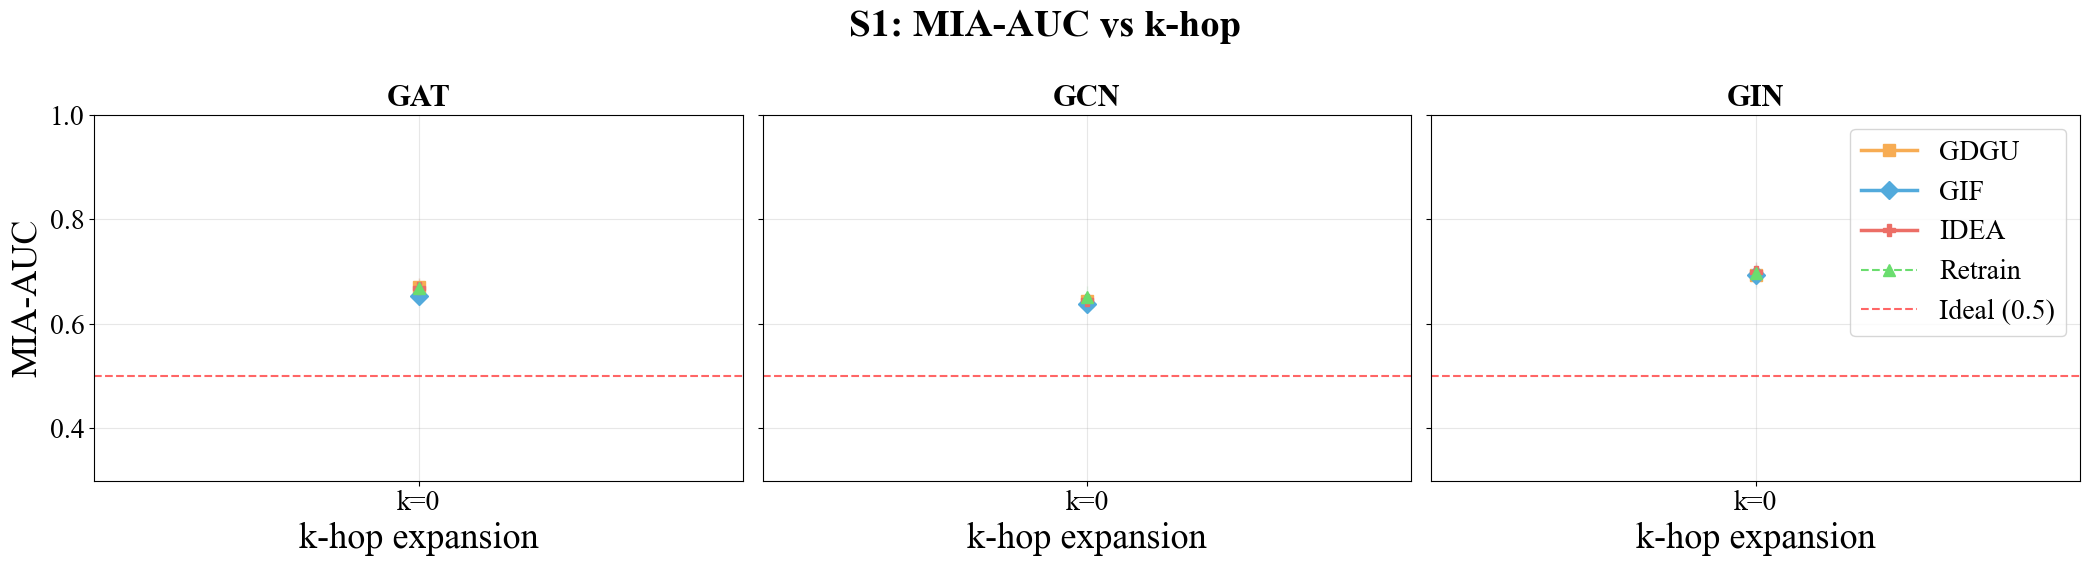

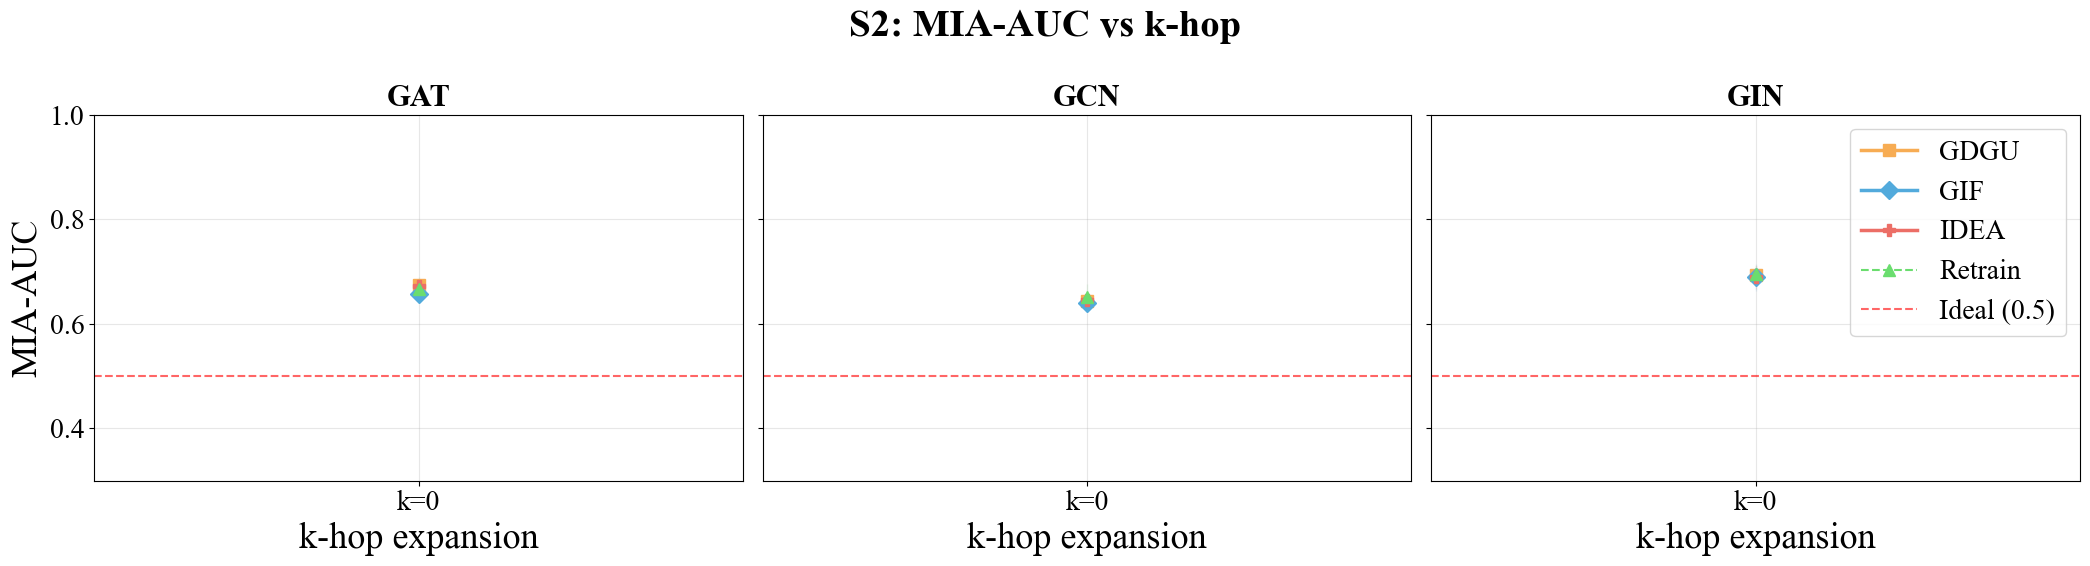

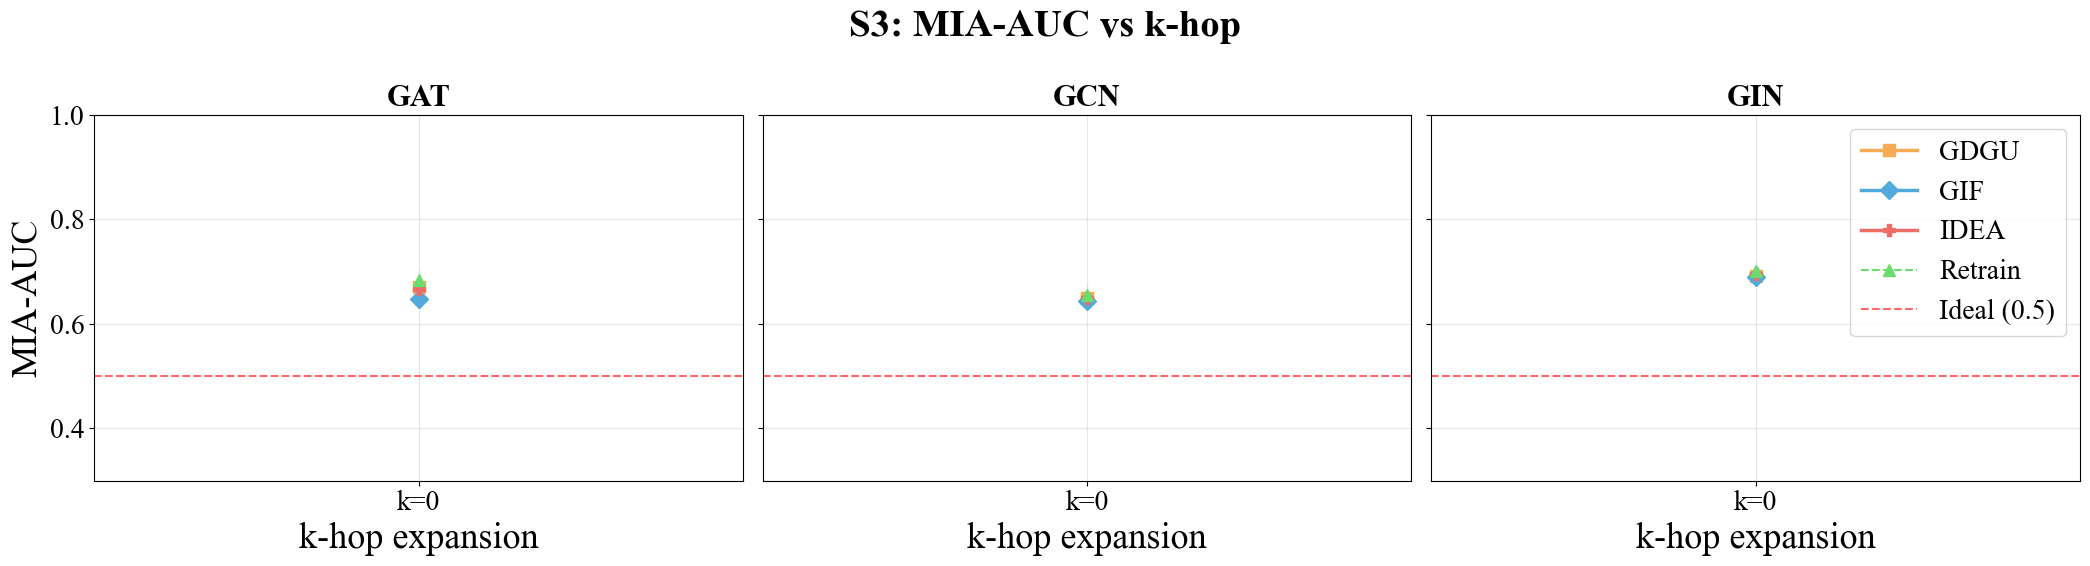

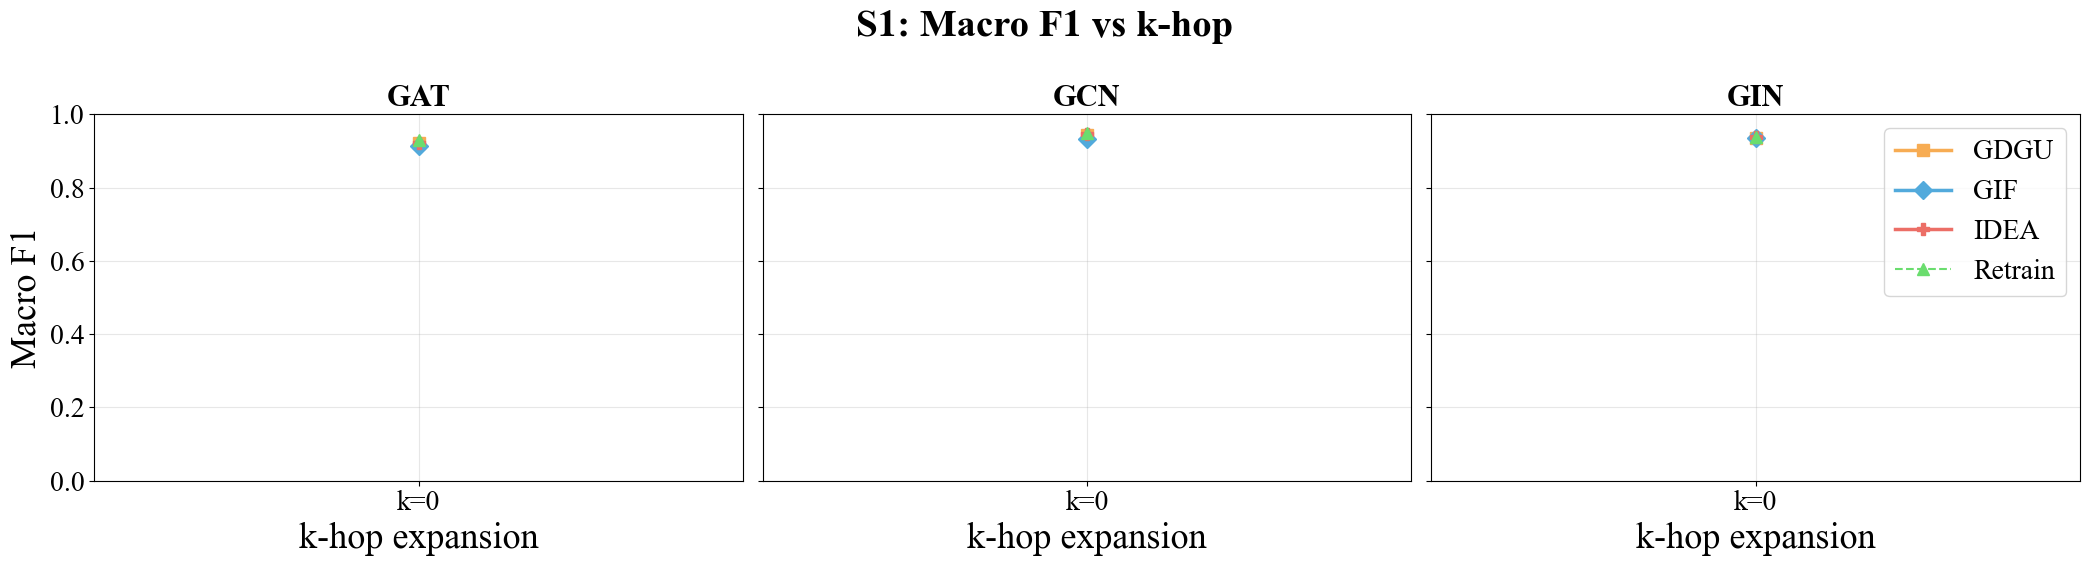

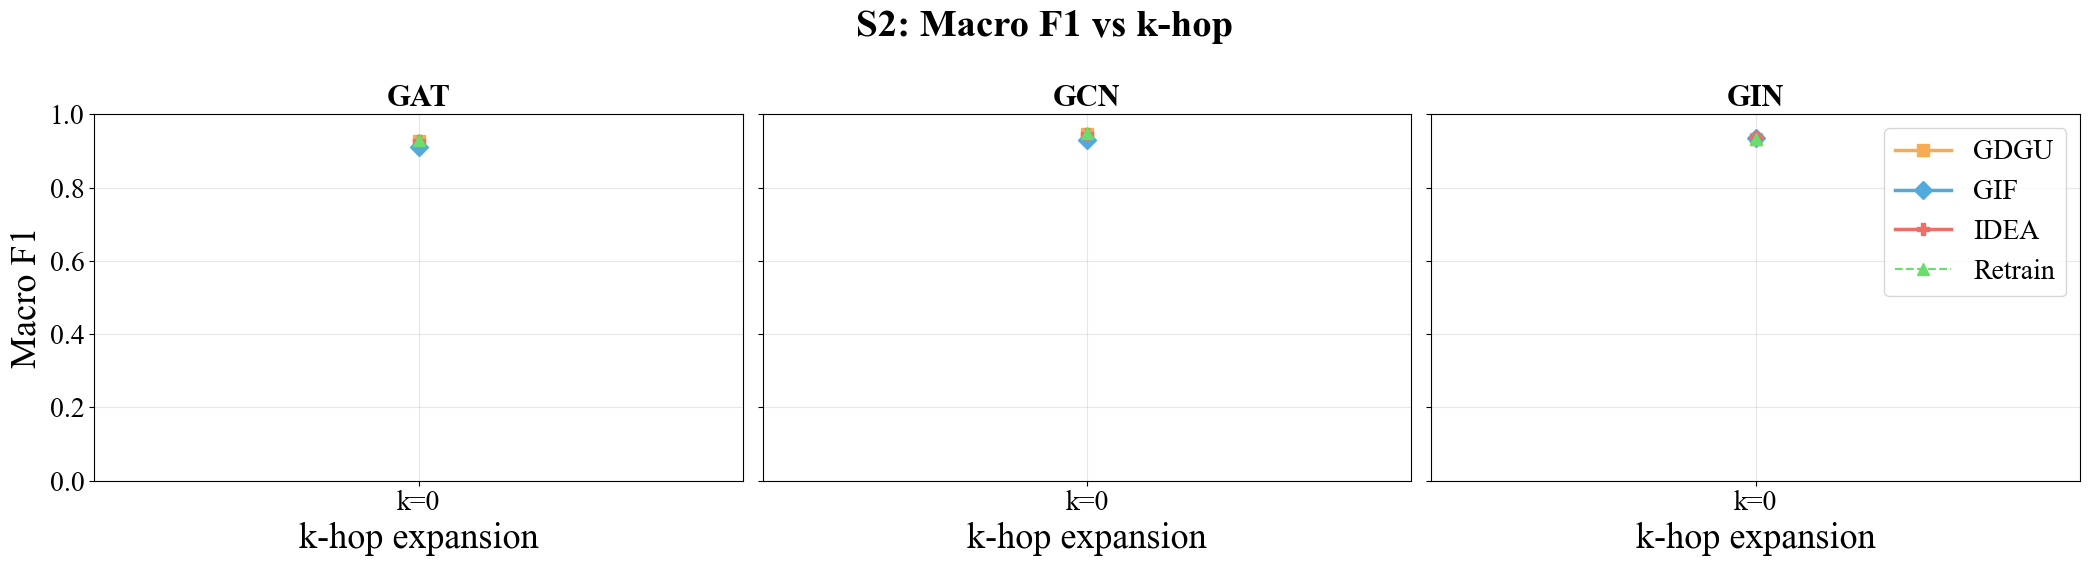

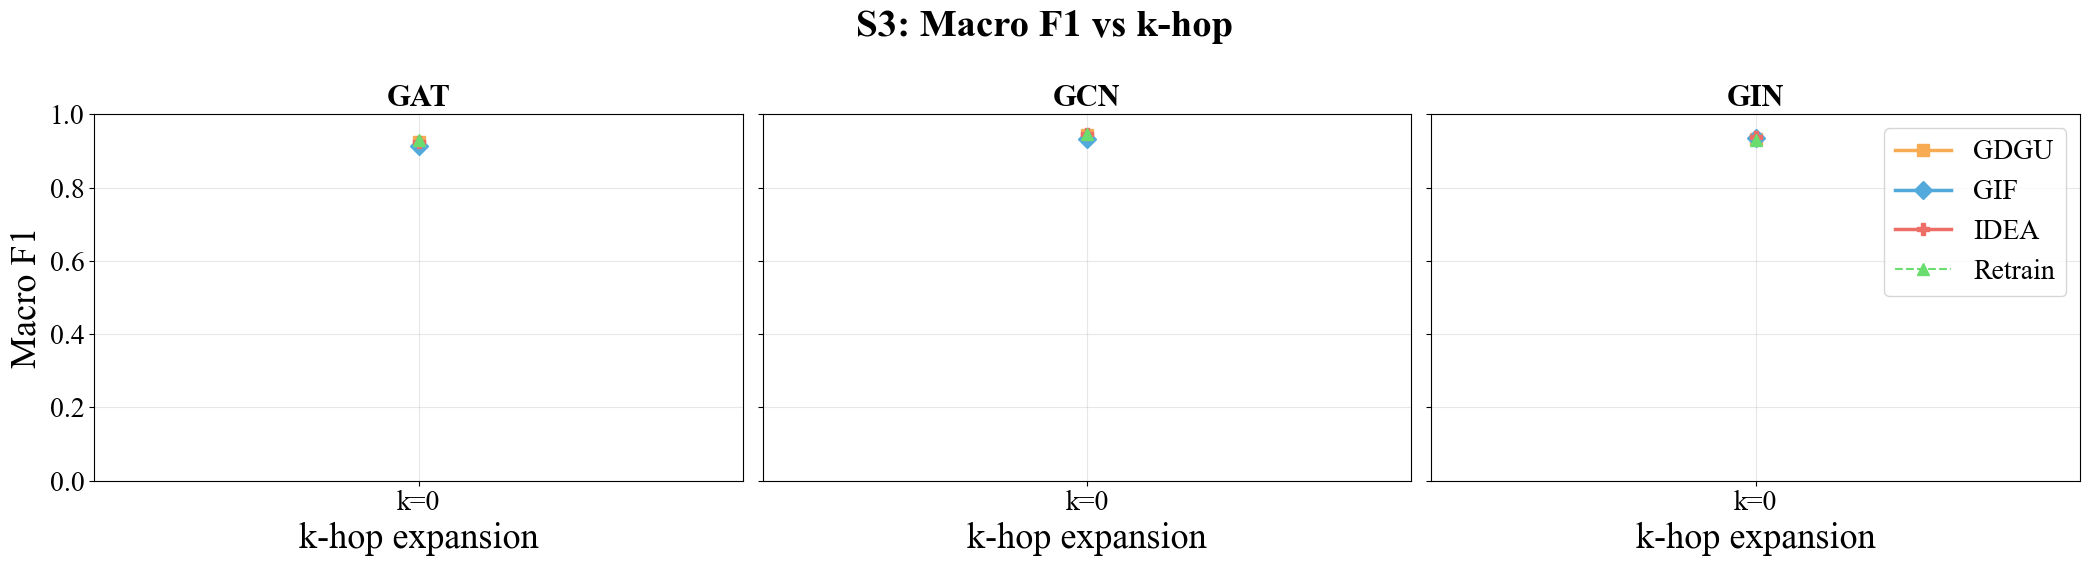

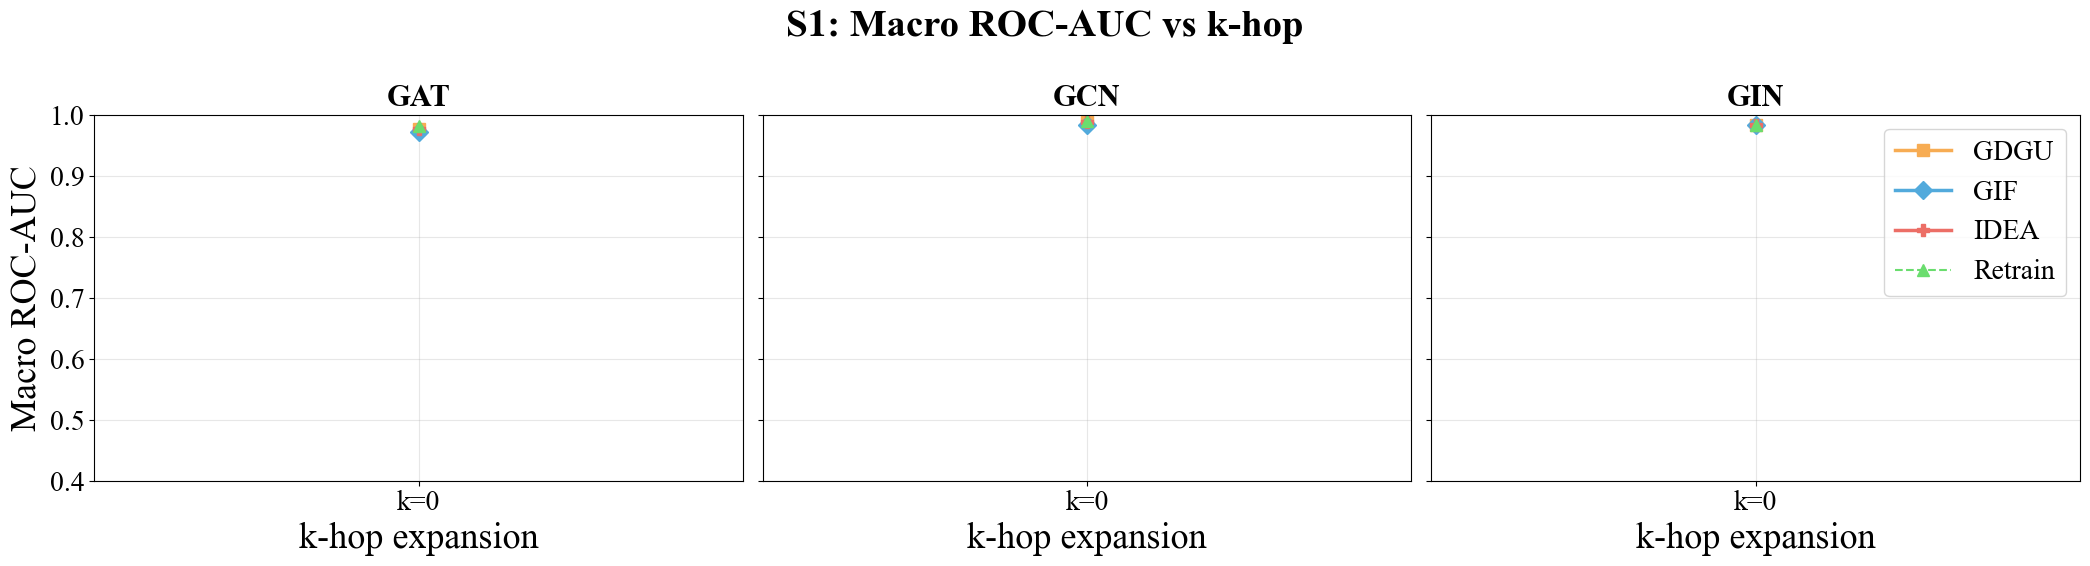

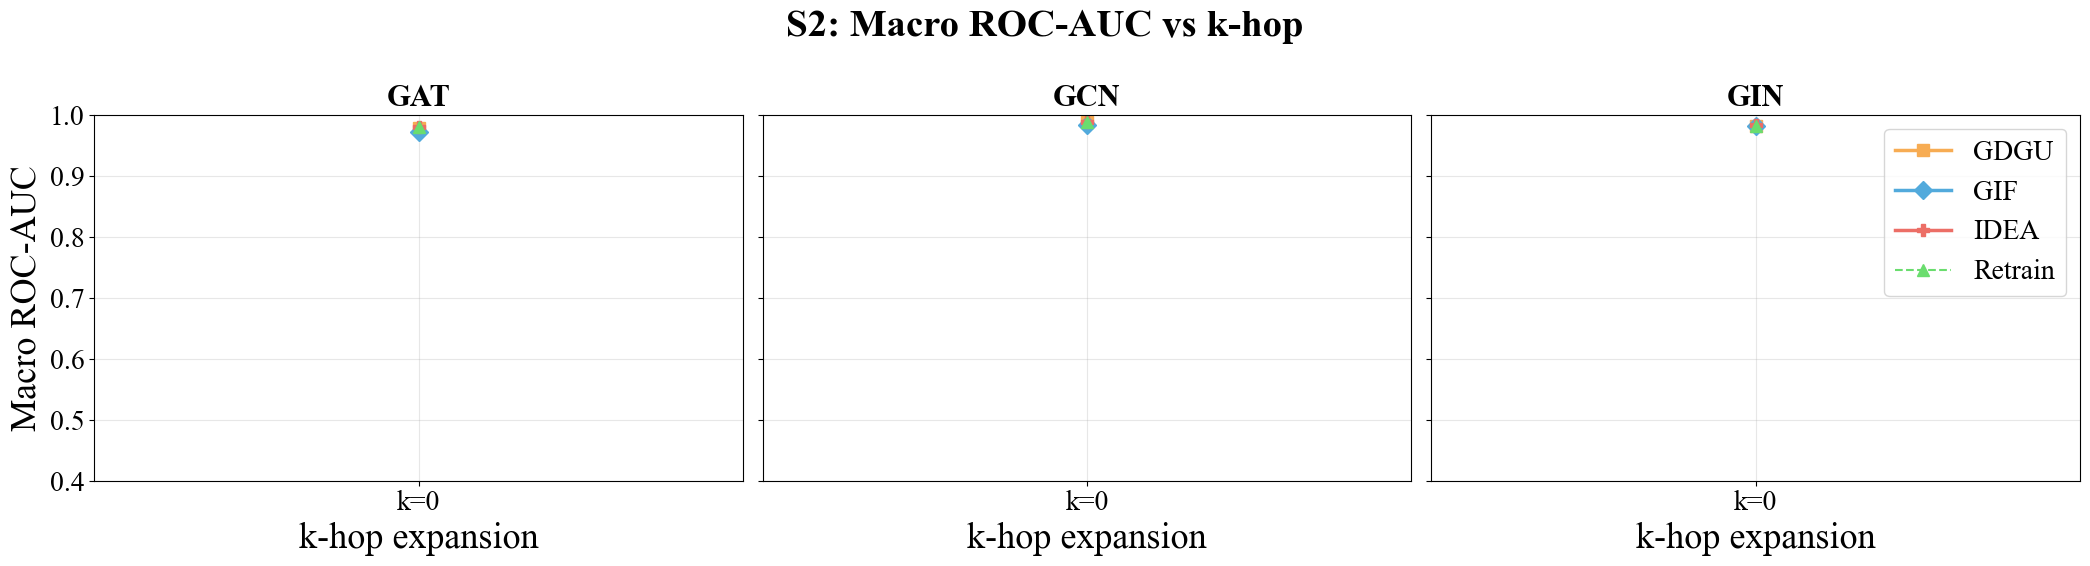

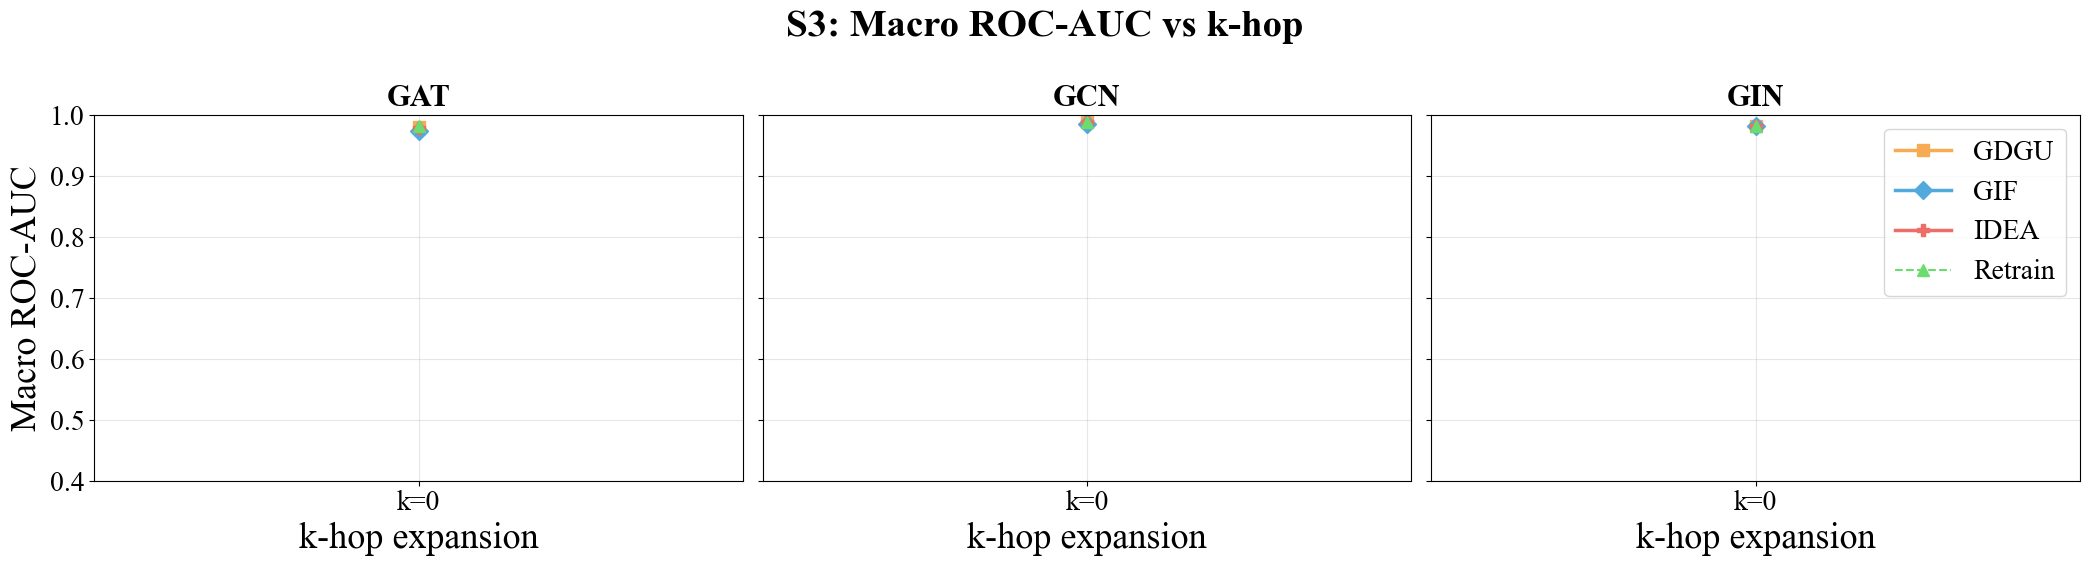

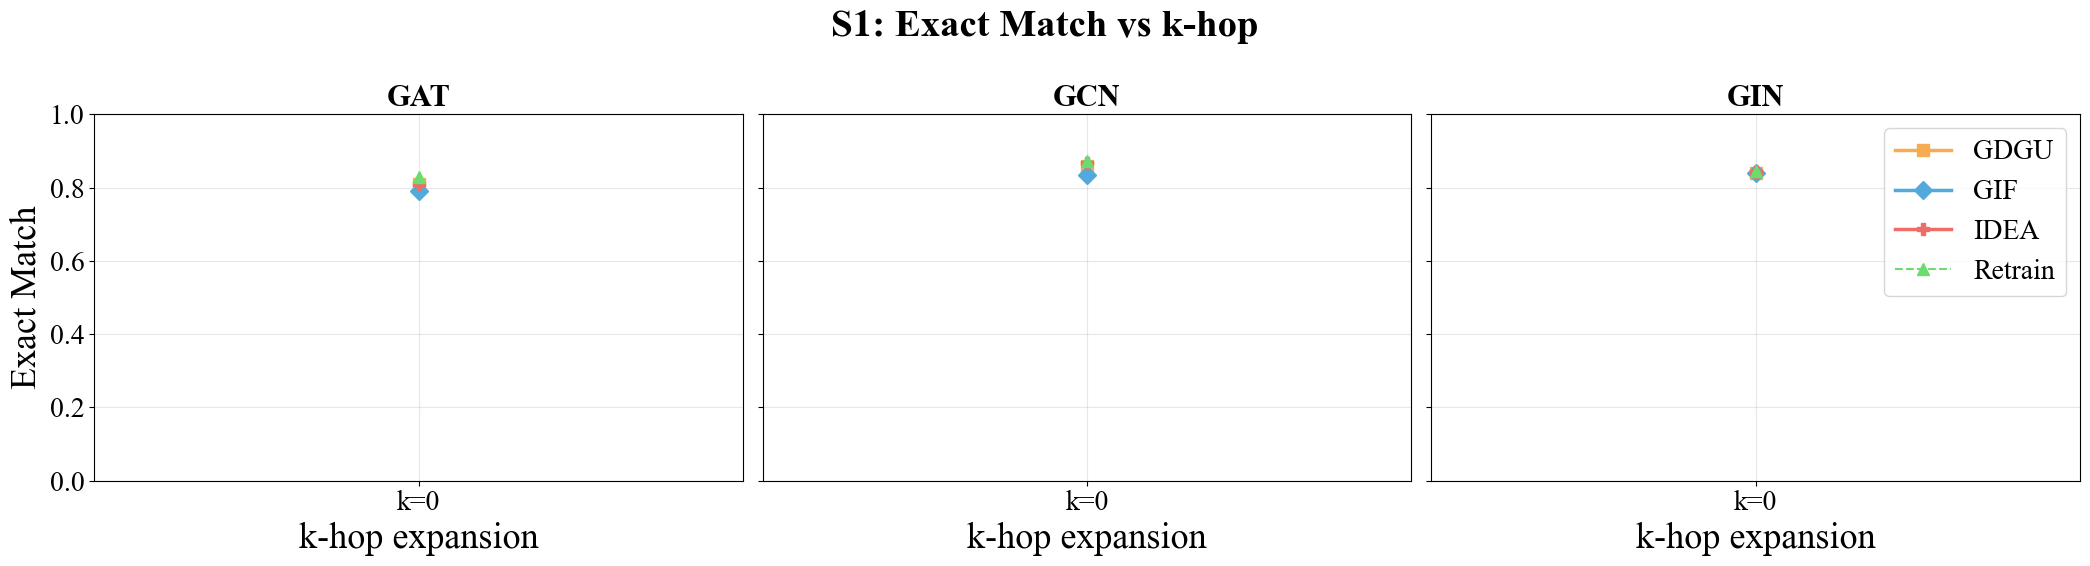

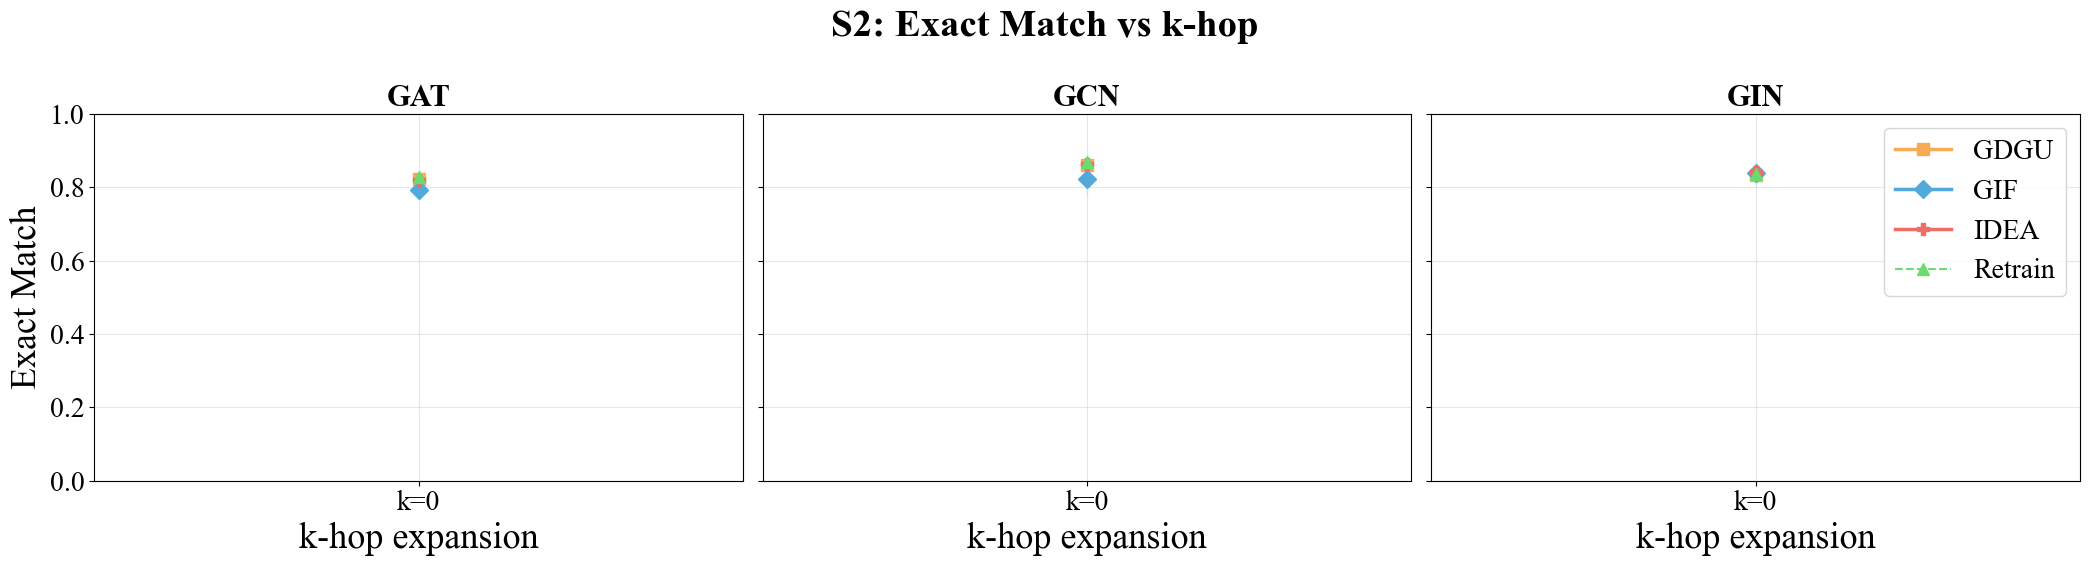

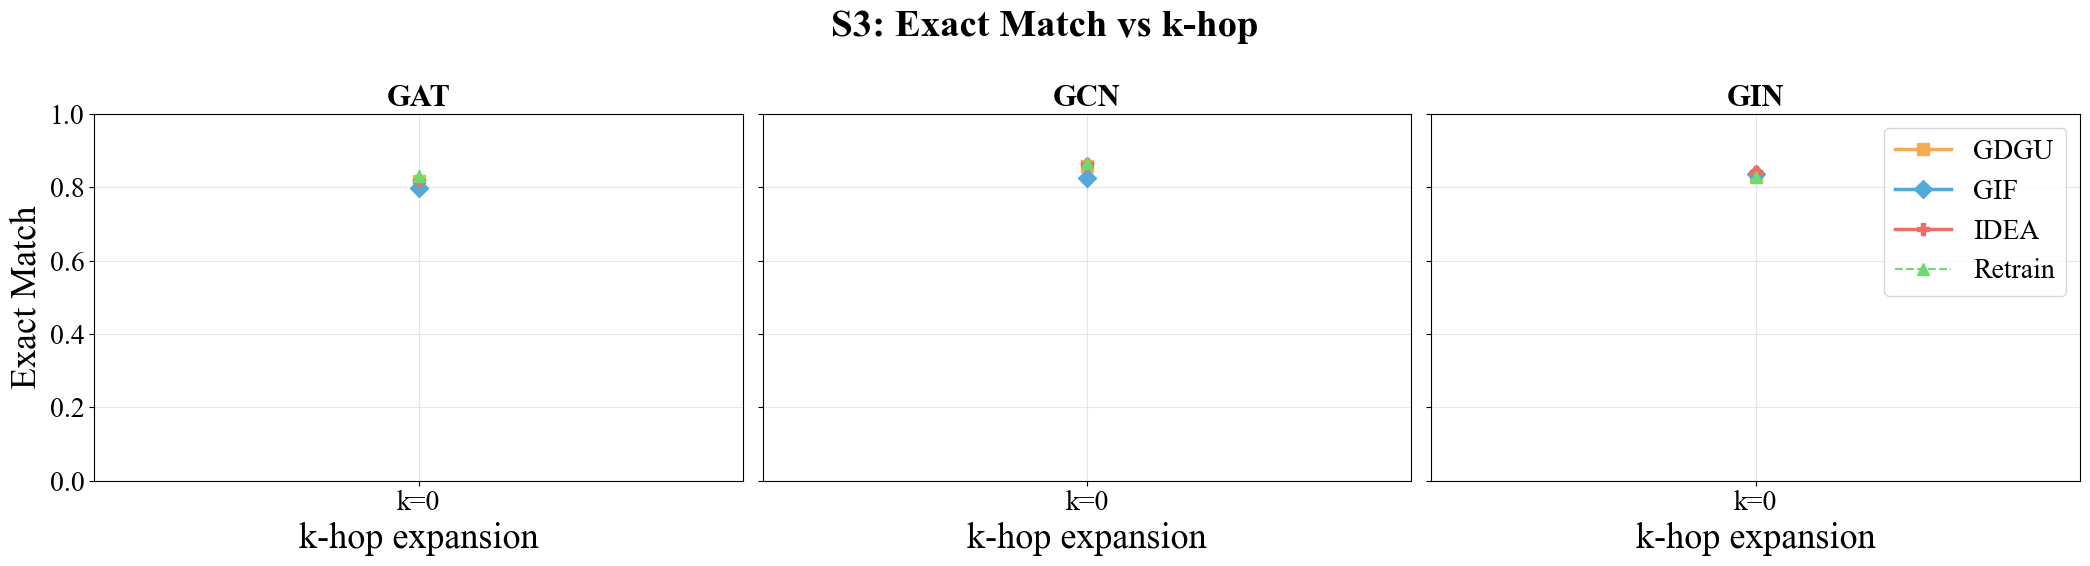

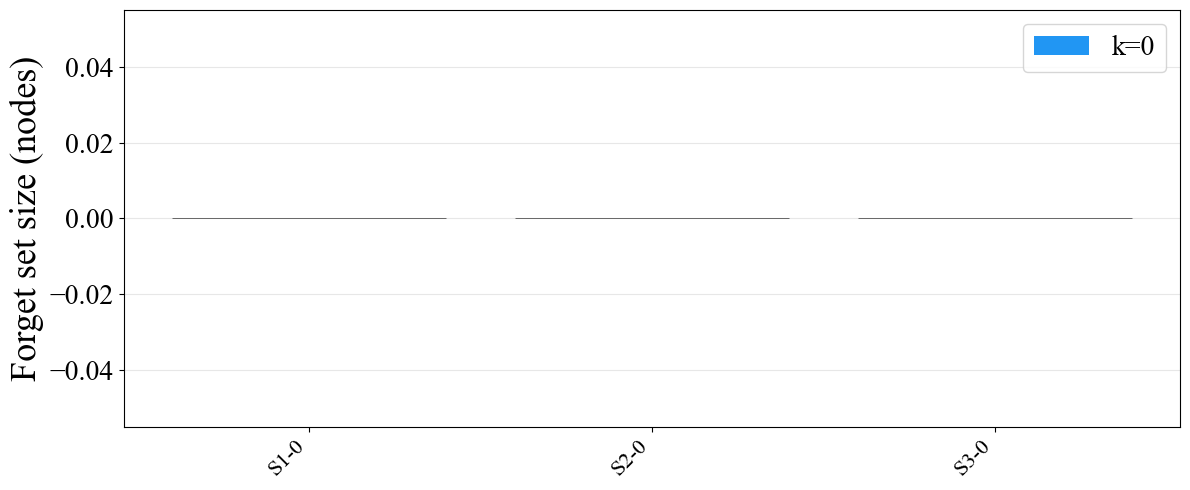


All figures saved to /home/Nanhong147/1P_WTT_NVD/Projects/4-GU_EV_loc/results/2026-04-20_21/ (prefix: 34bus_)

Figures saved to: /home/Nanhong147/1P_WTT_NVD/Projects/4-GU_EV_loc/results/2026-04-20_21/


In [3]:
# Cell 3 — Generate & save all figures to the same date folder
plot_all(df, str(RESULTS_DIR), scenarios, backbones, bus_system=BUS_SYSTEM)
print(f'\nFigures saved to: {RESULTS_DIR}/')

## Dual-channel (Scheme A) — V5.1

Compares single-channel (`{BUS}_results_raw.csv`) with dual-channel
(`{BUS}_dual_results_raw.csv`) produced in the same date folder.

- **Detection preservation** — Det_Acc / Det_AUC / Det_F1 should stay
  roughly constant across Original / GDGU / GIF / IDEA / Retrain in the
  dual-channel run, confirming the graph channel is frozen during
  unlearning.
- **MIA comparison** — MIA_forget in the dual-channel run should be
  closer to 0.5 than in the single-channel baseline (the Scheme A
  hypothesis).

In [4]:
# Cell — Load dual-channel results (Scheme A)
from src.visualization import (load_results, plot_det_preservation,
                                plot_dual_vs_nondual_mia,
                                summarize_dual_vs_nondual)

try:
    df_dual, scenarios_dual, backbones_dual = load_results(
        str(RESULTS_DIR), BUS_SYSTEM, tag='dual')
    HAS_DUAL = True
except FileNotFoundError as e:
    print(f'No dual-channel CSV found in {RESULTS_DIR}:\n  {e}')
    print('Run `python scripts/train.py --bus 34bus --dual` to generate it.')
    HAS_DUAL = False

Loaded 450 rows from /home/Nanhong147/1P_WTT_NVD/Projects/4-GU_EV_loc/results/2026-04-20_21/34bus_dual_results_raw.csv
  Backbones : ['GAT', 'GCN', 'GIN']
  Scenarios : ['S1-0', 'S2-0', 'S3-0']
  Methods   : ['GDGU', 'GIF', 'IDEA', 'Original', 'Retrain']


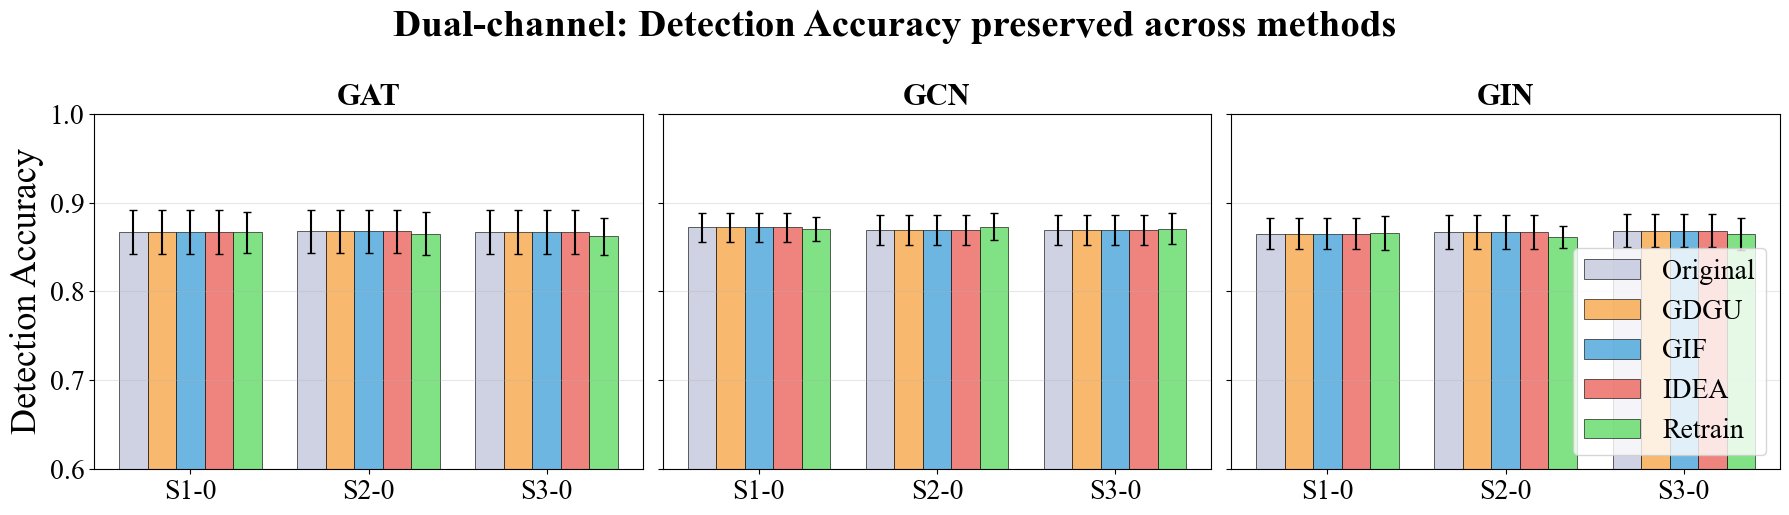

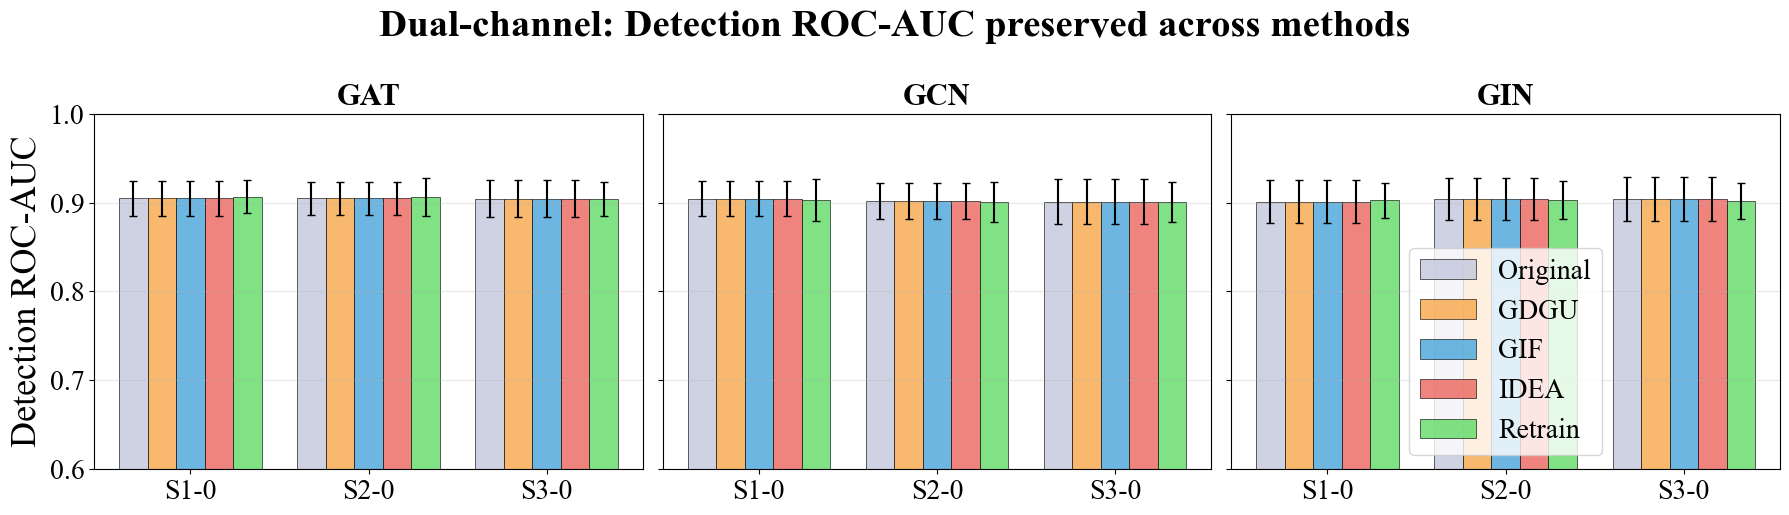

In [5]:
# Cell — Detection-metric preservation (dual only)
if HAS_DUAL:
    plot_det_preservation(
        df_dual,
        filepath=str(RESULTS_DIR / f'{BUS_SYSTEM}_dual_Det_Acc_preservation.pdf'),
        scenarios=scenarios_dual, backbones=backbones_dual,
        metric='Det_Acc', ylabel='Detection Accuracy', ylim=(0.6, 1.0))

    if 'Det_AUC' in df_dual.columns:
        plot_det_preservation(
            df_dual,
            filepath=str(RESULTS_DIR / f'{BUS_SYSTEM}_dual_Det_AUC_preservation.pdf'),
            scenarios=scenarios_dual, backbones=backbones_dual,
            metric='Det_AUC', ylabel='Detection ROC-AUC', ylim=(0.6, 1.0))

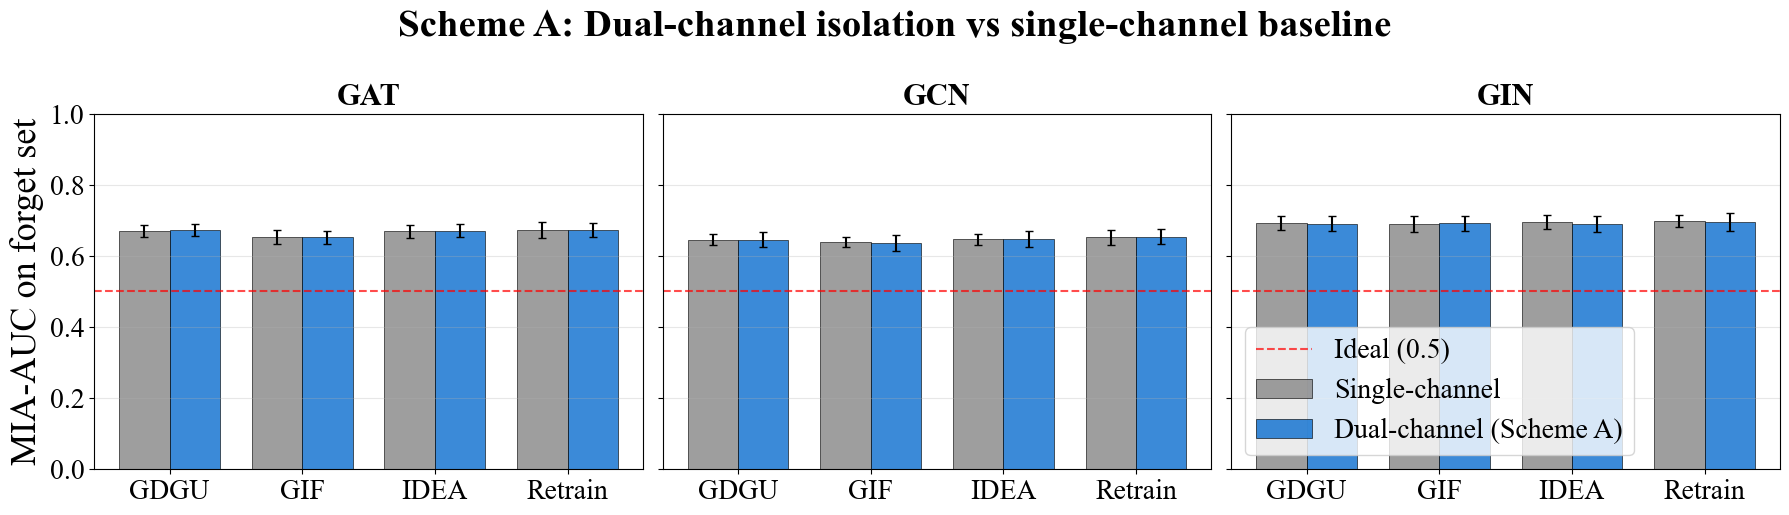

,Backbone,Method,n_nondual,n_dual,MIA_AUC_nondual,MIA_AUC_dual,MIA_forget_nondual,MIA_forget_dual,ExMatch_nondual,ExMatch_dual,Macro_ROC_nondual,Macro_ROC_dual,Macro_F1_nondual,Macro_F1_dual,Time_nondual,Time_dual
0,GAT,Original,30,30,nan±nan,nan±nan,nan±nan,nan±nan,0.827±0.018,0.825±0.021,0.981±0.003,0.981±0.003,0.929±0.007,0.929±0.008,69.701±14.926,85.947±15.267
1,GAT,GDGU,30,30,0.671±0.017,0.673±0.017,0.647±0.029,0.647±0.031,0.817±0.021,0.811±0.020,0.978±0.004,0.978±0.003,0.925±0.009,0.923±0.008,8.786±0.428,9.374±0.354
2,GAT,GIF,30,30,0.653±0.019,0.652±0.018,0.635±0.023,0.632±0.025,0.793±0.020,0.789±0.020,0.972±0.005,0.972±0.004,0.913±0.009,0.912±0.008,6.767±0.080,6.842±0.107
3,GAT,IDEA,30,30,0.669±0.018,0.671±0.017,0.646±0.029,0.646±0.029,0.815±0.024,0.811±0.018,0.978±0.004,0.978±0.003,0.924±0.009,0.924±0.007,14.905±0.351,15.507±0.218
4,GAT,Retrain,30,30,0.673±0.021,0.672±0.020,0.649±0.033,0.647±0.032,0.829±0.017,0.822±0.021,0.981±0.003,0.979±0.003,0.930±0.006,0.927±0.009,81.926±12.189,89.102±14.366
5,GCN,Original,30,30,nan±nan,nan±nan,nan±nan,nan±nan,0.864±0.017,0.863±0.016,0.988±0.003,0.988±0.002,0.947±0.007,0.946±0.006,50.502±10.069,61.449±11.700
6,GCN,GDGU,30,30,0.645±0.016,0.646±0.020,0.623±0.027,0.624±0.029,0.860±0.019,0.859±0.012,0.988±0.002,0.988±0.002,0.945±0.005,0.945±0.004,5.964±0.172,6.535±0.049
7,GCN,GIF,30,30,0.640±0.014,0.637±0.022,0.622±0.023,0.620±0.028,0.828±0.036,0.834±0.019,0.984±0.004,0.984±0.003,0.931±0.011,0.935±0.007,3.754±0.041,3.793±0.037
8,GCN,IDEA,30,30,0.647±0.016,0.648±0.021,0.625±0.025,0.626±0.030,0.865±0.018,0.861±0.013,0.988±0.002,0.988±0.002,0.946±0.005,0.945±0.005,9.264±0.272,9.852±0.190
9,GCN,Retrain,30,30,0.652±0.022,0.654±0.021,0.630±0.029,0.632±0.032,0.869±0.021,0.861±0.015,0.989±0.002,0.988±0.002,0.948±0.007,0.945±0.006,53.716±9.856,64.984±13.663


Summary saved to /home/Nanhong147/1P_WTT_NVD/Projects/4-GU_EV_loc/results/2026-04-20_21/34bus_dual_vs_nondual_summary.csv


In [6]:
# Cell — Dual vs Non-dual MIA_forget comparison
if HAS_DUAL:
    # Use the intersection of scenarios present in both CSVs
    common_scens = {sk: sv for sk, sv in scenarios.items()
                    if sk in scenarios_dual}
    common_bbs = [bb for bb in backbones if bb in backbones_dual]

    plot_dual_vs_nondual_mia(
        df_nondual=df, df_dual=df_dual,
        filepath=str(RESULTS_DIR / f'{BUS_SYSTEM}_dual_vs_nondual_MIA.pdf'),
        scenarios=common_scens, backbones=common_bbs,
        mia_col='MIA_AUC')

    summary = summarize_dual_vs_nondual(df, df_dual)
    display(summary)
    summary.to_csv(RESULTS_DIR / f'{BUS_SYSTEM}_dual_vs_nondual_summary.csv',
                   index=False)
    print(f"Summary saved to {RESULTS_DIR}/{BUS_SYSTEM}_dual_vs_nondual_summary.csv")